# 논문의 빈도주의 통계분석을 numpy 로 재현하기

**대상 논문**: 이선빈·김지현(2025), 「학부 유학생의 한국어 쓰기 효능감·호감도·상위인지 전략 사용 양상 연구」, 『작문연구』 65, 7-41.
**데이터**: `survey_data.csv` — 논문의 기술통계를 재현하도록 생성한 시뮬레이션 설문 자료(172명, 5점 리커트 51문항).

논문은 SPSS 27.0 으로 다음 분석을 수행했다(논문 III.3 "분석 방법").

| 논문의 표 | 분석 | 이 노트북의 절 |
|---|---|---|
| <표 1> | 연구 대상자 빈도·비율 | 2 |
| <표 4> | 쓰기 경험·요구도 빈도·비율 (복수 응답) | 3 |
| <표 3> | 문항 신뢰도 Cronbach's α | 4 |
| <표 5> | 하위 척도 평균·표준편차 | 5 |
| <표 6> | 항목별 상위·하위 1순위 문항 | 6 |
| <표 7> | 피어슨 상관 분석과 유의성 검정 | 7 |
| <표 8>, <표 9> | 한국어 수준(TOPIK)별 일원분산분석 + Scheffé 사후검정 | 8 |
| <표 10> | 다중회귀분석 (B, SE, β, t, p, VIF, F, R², adj R², Durbin–Watson) | 9 |

**진행 방식**

- 각 분석마다 ① 논문 표의 **원문 캡처 이미지** → ② **수식과 통계적·직관적 의미** 설명 → ③ **numpy 기본 연산으로 구현한 코드** → ④ 논문 수치와 나란히 비교, 의 순서로 진행한다.
- 통계량은 모두 numpy 의 배열 연산(합, 평균, 행렬곱, 역행렬)으로 직접 계산한다. 라이브러리 함수(`scipy.stats.pearsonr`, `f_oneway`, `statsmodels` 등)는 쓰지 않는다. 단, **p-값**은 t 분포·F 분포의 꼬리 확률이 필요하므로 그 적분값만 `scipy.stats.t.sf`, `scipy.stats.f.sf` 로 구한다(수치적분 자체가 분석 논리는 아니므로).
- 표본 분산·표준편차는 SPSS 와 같이 n−1 로 나눈다.

**빈도주의(frequentist) 관점 한 줄 요약**: 모집단의 참값(평균, 상관, 효과)은 고정된 미지수이고, 우리가 가진 172명은 그 모집단에서 뽑힌 하나의 표본이다. "이 표본을 무한히 다시 뽑는다면 통계량이 어떻게 흔들릴까"를 확률 모형(t, F 분포)으로 계산해, 관측된 값이 "효과가 없다"는 가정(귀무가설)과 얼마나 양립하기 어려운지를 p-값으로 표현한다.

## 1. 데이터 준비와 하위 척도 점수

논문은 문항 응답을 하위 요인별로 묶어 **하위 척도 점수 = 해당 문항들의 평균**으로 분석 변수를 만들었다(<표 5>의 값이 1~5 범위이므로 합산이 아닌 평균임을 알 수 있다).
응답자 $i$ 의 하위 척도 $s$ 점수는

$$
S_{is} = \frac{1}{k_s}\sum_{j \in s} x_{ij}
$$

이 노트북의 모든 분석(상관, 분산분석, 회귀)은 이 8개 하위 척도 점수 행렬 $S$ (172 × 8) 위에서 이루어진다.

In [1]:
import numpy as np
import pandas as pd
from scipy import stats            # p-값 계산용 분포 꼬리확률(t.sf, f.sf)에만 사용
pd.set_option("display.width", 140)

df = pd.read_csv("survey_data.csv")
N = len(df)

# 논문 <표 3> 의 하위 요인 구성
SUB = {
    "발상":     [f"SE{i:02d}" for i in range(1, 6)],
    "규칙":     [f"SE{i:02d}" for i in range(6, 11)],
    "자기조절": [f"SE{i:02d}" for i in range(11, 17)],
    "긍정":     ["LW17", "LW19"],
    "부정":     ["LW18", "LW20"],
    "계획":     [f"MC{i:02d}" for i in range(1, 11)],
    "작성":     [f"MC{i:02d}" for i in range(11, 21)],
    "검토":     [f"MC{i:02d}" for i in range(21, 32)],
}
names = list(SUB)
# 하위 척도 점수: 문항 평균 (행 방향)
S = np.column_stack([df[cols].to_numpy(dtype=float).mean(axis=1) for cols in SUB.values()])   # (172, 8)
print("N =", N, "  S.shape =", S.shape)
print(pd.DataFrame(S, columns=names).head().round(2))

N = 172   S.shape = (172, 8)
    발상   규칙  자기조절   긍정   부정   계획   작성    검토
0  4.2  4.4  4.33  4.0  3.0  4.7  4.9  4.91
1  4.0  3.8  3.00  3.0  3.0  3.1  3.8  3.64
2  2.6  2.2  2.17  2.5  4.0  2.8  2.1  2.27
3  2.2  2.4  2.67  3.0  5.0  3.0  3.7  3.27
4  3.4  3.8  3.67  5.0  3.0  4.6  4.3  3.09


## 2. <표 1> 연구 대상자 기본 정보 — 빈도와 비율

범주형 변수의 **빈도(count)** 는 각 값이 몇 번 나타나는지 센 것이고, **비율(%)** 은 그것을 전체 $N$ 으로 나눈 것이다.

$$
\text{비율}_c = \frac{n_c}{N}\times 100, \qquad \sum_c n_c = N
$$

`np.unique(..., return_counts=True)` 가 곧 빈도표다. 이 표는 "누구를 조사했는가"를 밝히는 것으로, 이후 결과를 어떤 모집단(부산 소재 두 대학의 학부 유학생)으로 일반화할 수 있는지의 범위를 정해 준다. 예컨대 베트남 국적이 62.8 % 이므로 결과 해석은 베트남 학습자의 특성에 크게 좌우될 수 있다.

**논문 원문 캡처** — <표 1> 연구 대상자 기본 정보

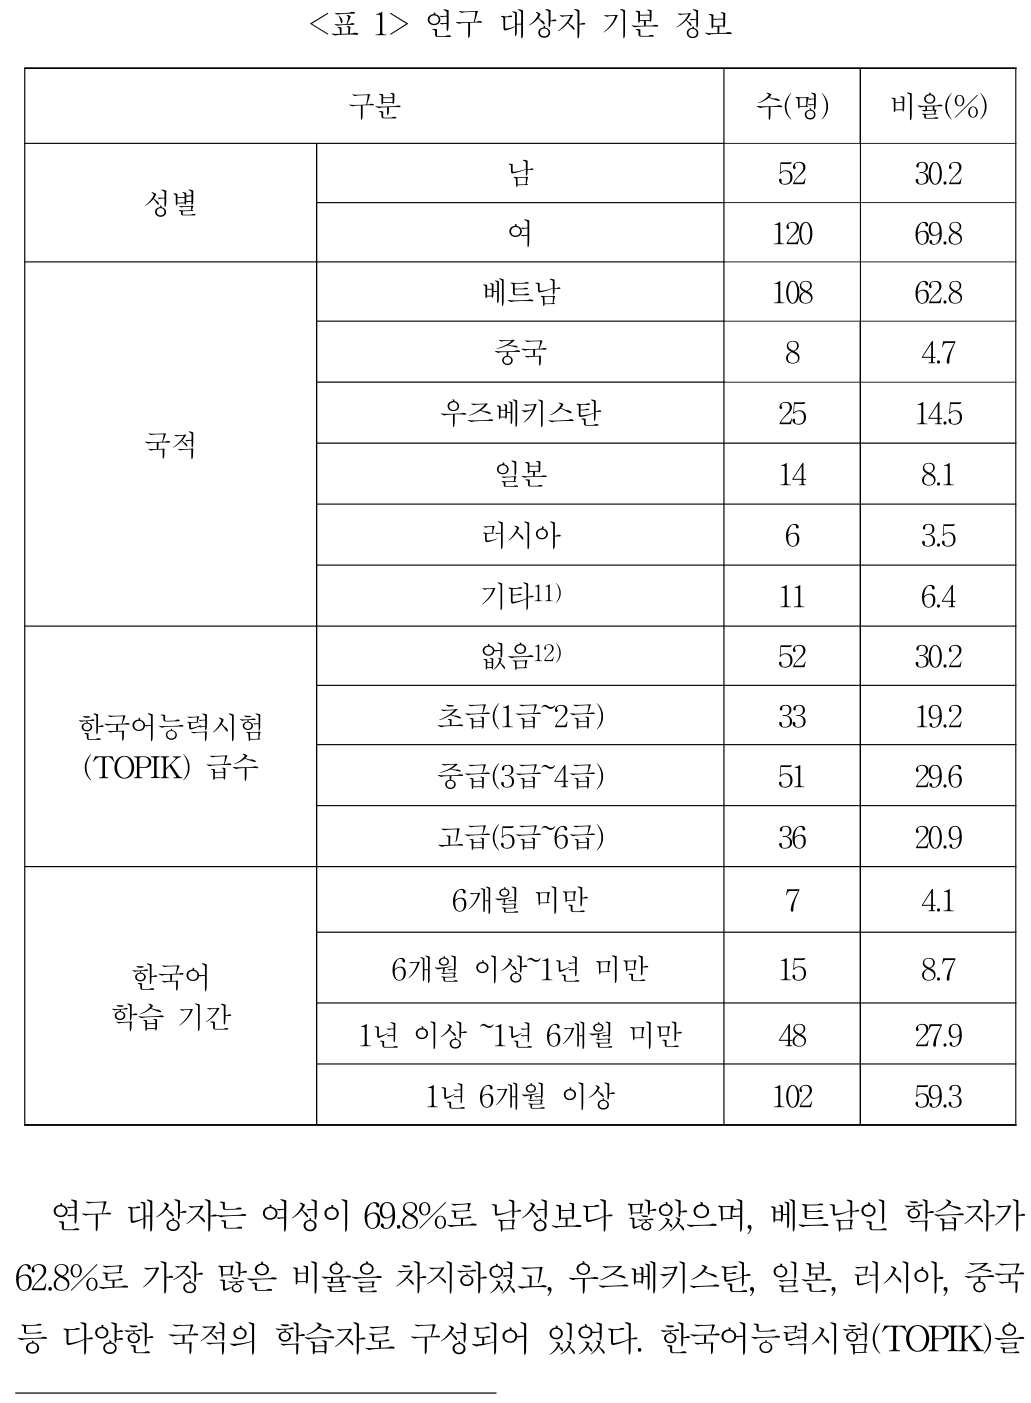

In [2]:
labels = {
    "gender":       {1: "남", 2: "여"},
    "nationality":  {1: "베트남", 2: "중국", 3: "우즈베키스탄", 4: "일본", 5: "러시아", 6: "기타"},
    "topik":        {0: "없음", 1: "초급(1~2급)", 2: "중급(3~4급)", 3: "고급(5~6급)"},
    "study_period": {1: "6개월 미만", 2: "6개월~1년 미만", 3: "1년~1년6개월 미만", 4: "1년6개월 이상"},
}
rows = []
for var, lab in labels.items():
    vals, cnt = np.unique(df[var].to_numpy(), return_counts=True)
    for v, c in zip(vals, cnt):
        rows.append([var, lab[v], int(c), round(100 * c / N, 1)])
tab1 = pd.DataFrame(rows, columns=["구분", "값", "수(명)", "비율(%)"])
print(tab1.to_string(index=False))

          구분           값  수(명)  비율(%)
      gender           남    52   30.2
      gender           여   120   69.8
 nationality         베트남   108   62.8
 nationality          중국     8    4.7
 nationality      우즈베키스탄    25   14.5
 nationality          일본    14    8.1
 nationality         러시아     6    3.5
 nationality          기타    11    6.4
       topik          없음    52   30.2
       topik    초급(1~2급)    33   19.2
       topik    중급(3~4급)    51   29.7
       topik    고급(5~6급)    36   20.9
study_period      6개월 미만     7    4.1
study_period   6개월~1년 미만    15    8.7
study_period 1년~1년6개월 미만    48   27.9
study_period    1년6개월 이상   102   59.3


## 3. <표 4> 학습자의 쓰기 경험과 요구도 — 복수 응답의 비율

이 표에서 '대학에서 수행한 쓰기'와 '어려움을 느끼는 쓰기 과제'는 **복수 응답**이다. 이 경우 비율의 분모를 무엇으로 두느냐에 따라 두 종류의 비율이 있다.

- **응답 수 기준**: $\dfrac{n_c}{\sum_c n_c}\times 100$ — 전체 응답(체크 표시) 가운데 그 항목의 몫. 항목별 비율의 합이 100 %가 된다.
- **응답자 수 기준**: $\dfrac{n_c}{N}\times 100$ — 응답자 172명 가운데 그 항목을 고른 사람의 몫. 합이 100 %를 넘는다.

논문의 값(발표문 54명 = 26.1 %)은 $54/207$ 로, 전체 응답 수 207 을 분모로 한 **응답 수 기준** 비율이다. 반면 '필요한 요소'는 단일 선택이라 두 방식이 같다($\sum n_c = 172$). 복수 응답 비율을 읽을 때는 "학습자의 26 %가 발표문을 썼다"가 아니라 "쓰기 경험 응답의 26 %가 발표문이었다"로 읽어야 한다는 점이 실용적 교훈이다.

**논문 원문 캡처** — <표 4> 학습자의 쓰기 경험과 요구도 결과

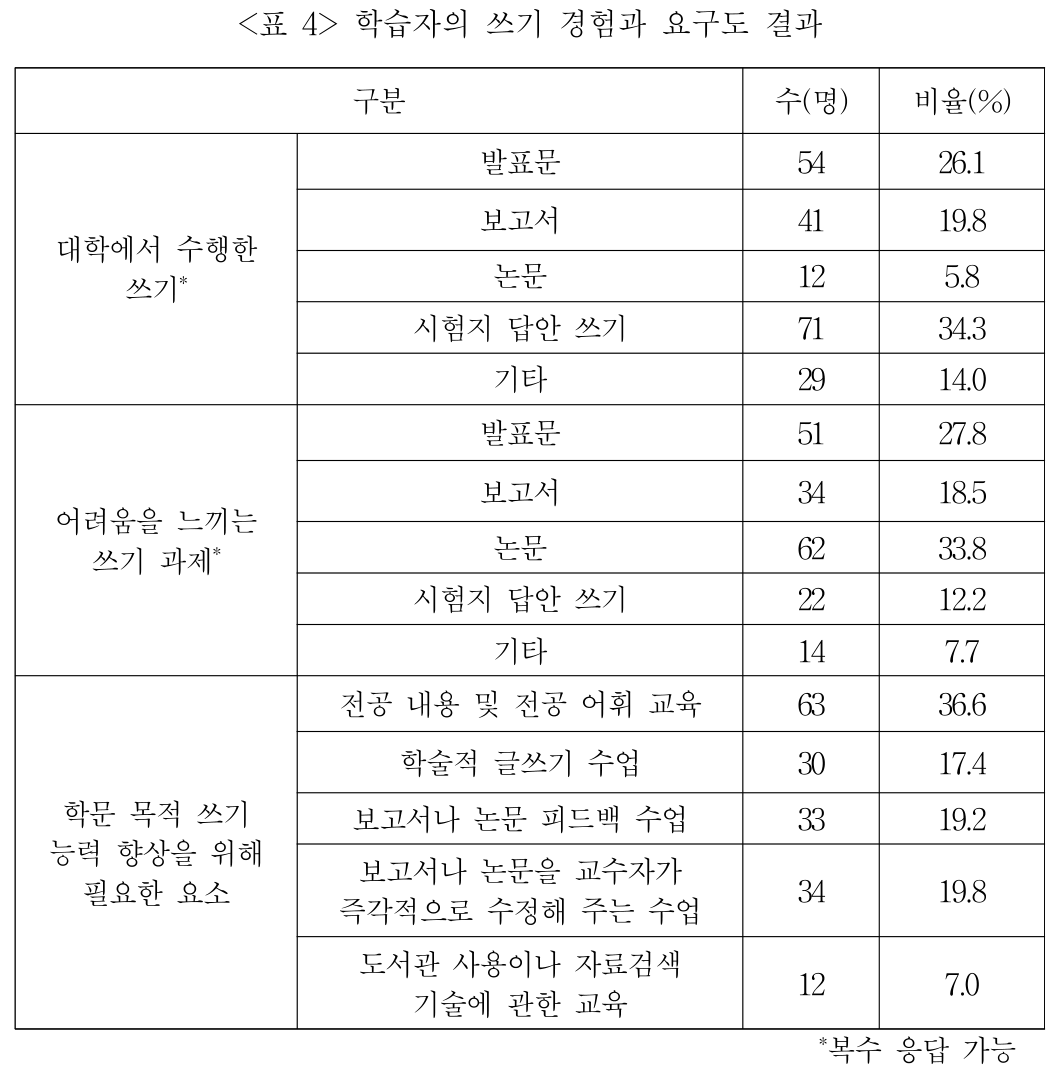

In [3]:
groups = {
    "대학에서 수행한 쓰기*":   {"exp_presentation": "발표문", "exp_report": "보고서", "exp_thesis": "논문", "exp_exam": "시험지 답안 쓰기", "exp_other": "기타"},
    "어려움을 느끼는 쓰기 과제*": {"diff_presentation": "발표문", "diff_report": "보고서", "diff_thesis": "논문", "diff_exam": "시험지 답안 쓰기", "diff_other": "기타"},
}
rows = []
for g, cols in groups.items():
    counts = np.array([df[c].to_numpy().sum() for c in cols])           # 0/1 열의 합 = 선택한 사람 수
    total_resp = counts.sum()                                           # 전체 응답 수 (복수 응답)
    for (c, lab), n_c in zip(cols.items(), counts):
        rows.append([g, lab, int(n_c), round(100 * n_c / total_resp, 1), round(100 * n_c / N, 1)])
need_lab = {1: "전공 내용 및 전공 어휘 교육", 2: "학술적 글쓰기 수업", 3: "보고서나 논문 피드백 수업", 4: "교수자가 즉각적으로 수정해 주는 수업", 5: "도서관 사용이나 자료검색 기술 교육"}
vals, cnt = np.unique(df["need"].to_numpy(), return_counts=True)
for v, c in zip(vals, cnt):
    rows.append(["필요한 요소 (단일 선택)", need_lab[v], int(c), round(100 * c / cnt.sum(), 1), round(100 * c / N, 1)])
tab4 = pd.DataFrame(rows, columns=["구분", "항목", "수(명)", "비율(%) 응답수 기준 = 논문", "비율(%) 응답자수 기준"])
print(tab4.to_string(index=False))

             구분                   항목  수(명)  비율(%) 응답수 기준 = 논문  비율(%) 응답자수 기준
   대학에서 수행한 쓰기*                  발표문    54               26.1           31.4
   대학에서 수행한 쓰기*                  보고서    41               19.8           23.8
   대학에서 수행한 쓰기*                   논문    12                5.8            7.0
   대학에서 수행한 쓰기*            시험지 답안 쓰기    71               34.3           41.3
   대학에서 수행한 쓰기*                   기타    29               14.0           16.9
어려움을 느끼는 쓰기 과제*                  발표문    51               27.9           29.7
어려움을 느끼는 쓰기 과제*                  보고서    34               18.6           19.8
어려움을 느끼는 쓰기 과제*                   논문    62               33.9           36.0
어려움을 느끼는 쓰기 과제*            시험지 답안 쓰기    22               12.0           12.8
어려움을 느끼는 쓰기 과제*                   기타    14                7.7            8.1
 필요한 요소 (단일 선택)     전공 내용 및 전공 어휘 교육    63               36.6           36.6
 필요한 요소 (단일 선택)           학술적 글쓰기 수업    30               17.4           17.4

## 4. <표 3> 문항 신뢰도 — Cronbach's α

$k$ 개 문항의 분산 $s_j^2$ 과 총점 $T_i=\sum_j x_{ij}$ 의 분산 $s_T^2$ 으로

$$
\alpha = \frac{k}{k-1}\left(1-\frac{\sum_{j=1}^{k}s_j^2}{s_T^2}\right)
$$

총점 분산은 $s_T^2=\sum_j s_j^2 + 2\sum_{j<l}s_{jl}$ 이므로, α 는 "총점의 변동 가운데 문항들이 **함께** 움직여서 생긴 부분(공분산)의 비중"이다. 문항들이 같은 것을 재면 함께 오르내려 α 가 1 에 가깝고, 서로 무관하면 0 에 가깝다.
논문은 모든 하위 요인에서 0.8 이상을 "양호한 내적 신뢰도"의 근거로 삼았다(관례: 0.7 수용, 0.8 양호, 0.9 우수).

numpy 구현은 단 세 줄이다: 열 방향 분산, 행 방향 합의 분산, 그리고 위 식.

**논문 원문 캡처** — <표 3> 쓰기 효능감 및 쓰기 상위인지 전략의 설문 문항 신뢰도

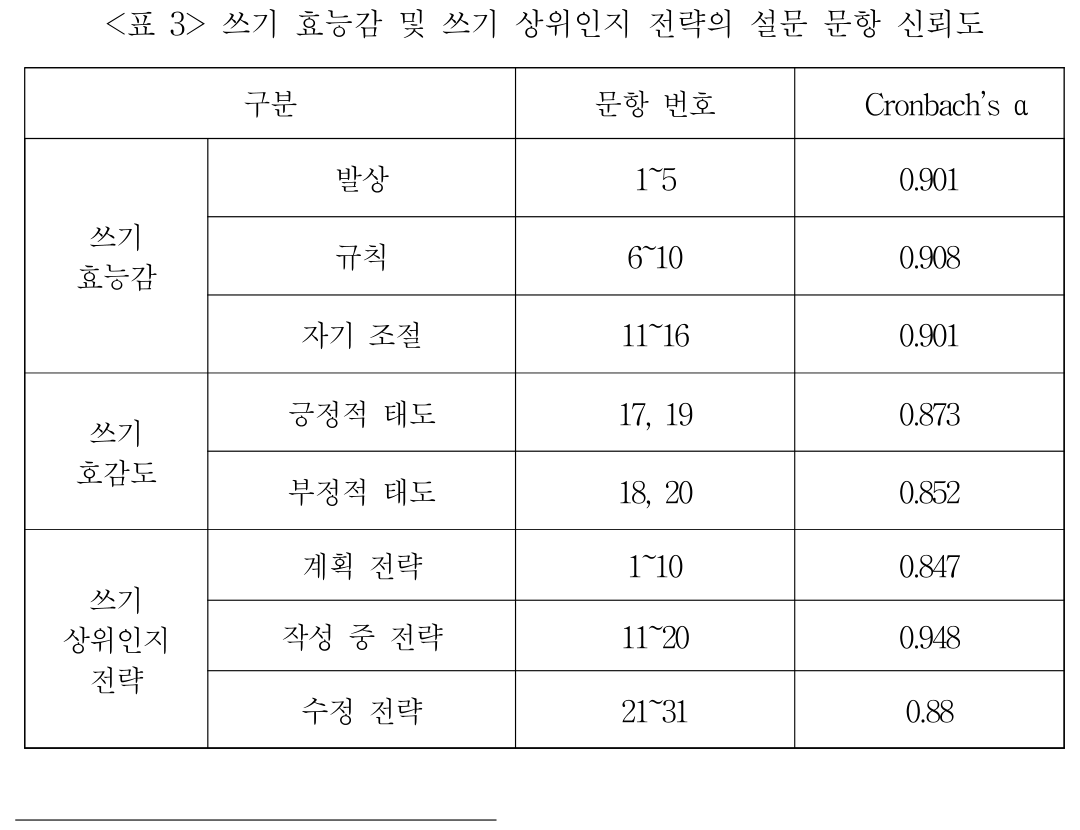

In [4]:
def cronbach_alpha(X):
    X = np.asarray(X, dtype=float)
    k = X.shape[1]
    return k / (k - 1) * (1 - X.var(axis=0, ddof=1).sum() / X.sum(axis=1).var(ddof=1))

paper_alpha = {"발상": .901, "규칙": .908, "자기조절": .901, "긍정": .873, "부정": .852, "계획": .847, "작성": .948, "검토": .880}
rows = [[n, f"{cols[0]}~{cols[-1]}", len(cols), paper_alpha[n], round(cronbach_alpha(df[cols]), 3)] for n, cols in SUB.items()]
tab3 = pd.DataFrame(rows, columns=["하위 요인", "문항", "k", "α (논문)", "α (numpy)"])
tab3["차이"] = (tab3["α (numpy)"] - tab3["α (논문)"]).round(3)
print(tab3.to_string(index=False))
print(f"\n최대 절대 차이 = {tab3['차이'].abs().max():.3f}")

하위 요인        문항  k  α (논문)  α (numpy)     차이
   발상 SE01~SE05  5   0.901      0.901  0.000
   규칙 SE06~SE10  5   0.908      0.905 -0.003
 자기조절 SE11~SE16  6   0.901      0.903  0.002
   긍정 LW17~LW19  2   0.873      0.866 -0.007
   부정 LW18~LW20  2   0.852      0.857  0.005
   계획 MC01~MC10 10   0.847      0.848  0.001
   작성 MC11~MC20 10   0.948      0.948  0.000
   검토 MC21~MC31 11   0.880      0.880  0.000

최대 절대 차이 = 0.007


## 5. <표 5> 쓰기 효능감·호감도·상위인지 전략의 기술통계 (M, SD)

하위 척도 점수 $S_{is}$ 의 표본 평균과 표본 표준편차:

$$
M_s = \frac{1}{N}\sum_{i} S_{is}, \qquad
SD_s = \sqrt{\frac{1}{N-1}\sum_i (S_{is}-M_s)^2}
$$

- **M** 은 "3 = 보통이다"를 기준으로 학습자들이 평균적으로 어느 쪽에 있는지, **SD** 는 학습자 사이의 개인차가 얼마나 큰지를 말한다. 논문은 "각 항목별 평균이 3 에 근접"함을 지적하고, 부정적 태도의 SD(1.03)가 가장 커 "학습자 변인에 따라 부정적 감정의 편차가 나타날 수 있다"고 해석했다 — 이 해석이 8절의 분산분석으로 이어진다.
- 표의 **'전체' 행**은 하위 척도 점수들을 다시 평균 낸 새 변수의 통계가 아니라, 하위 요인 행의 M 과 SD 를 **단순 산술평균**한 값이다(예: 효능감 전체 M = (3.29+3.33+3.35)/3 = 3.32, SD = (0.73+0.71+0.73)/3 = 0.72). 아래 코드는 같은 방식으로 계산해 이를 확인한다.

**논문 원문 캡처** — <표 5> 쓰기 효능감, 호감도, 상위인지 전략 기술통계 결과

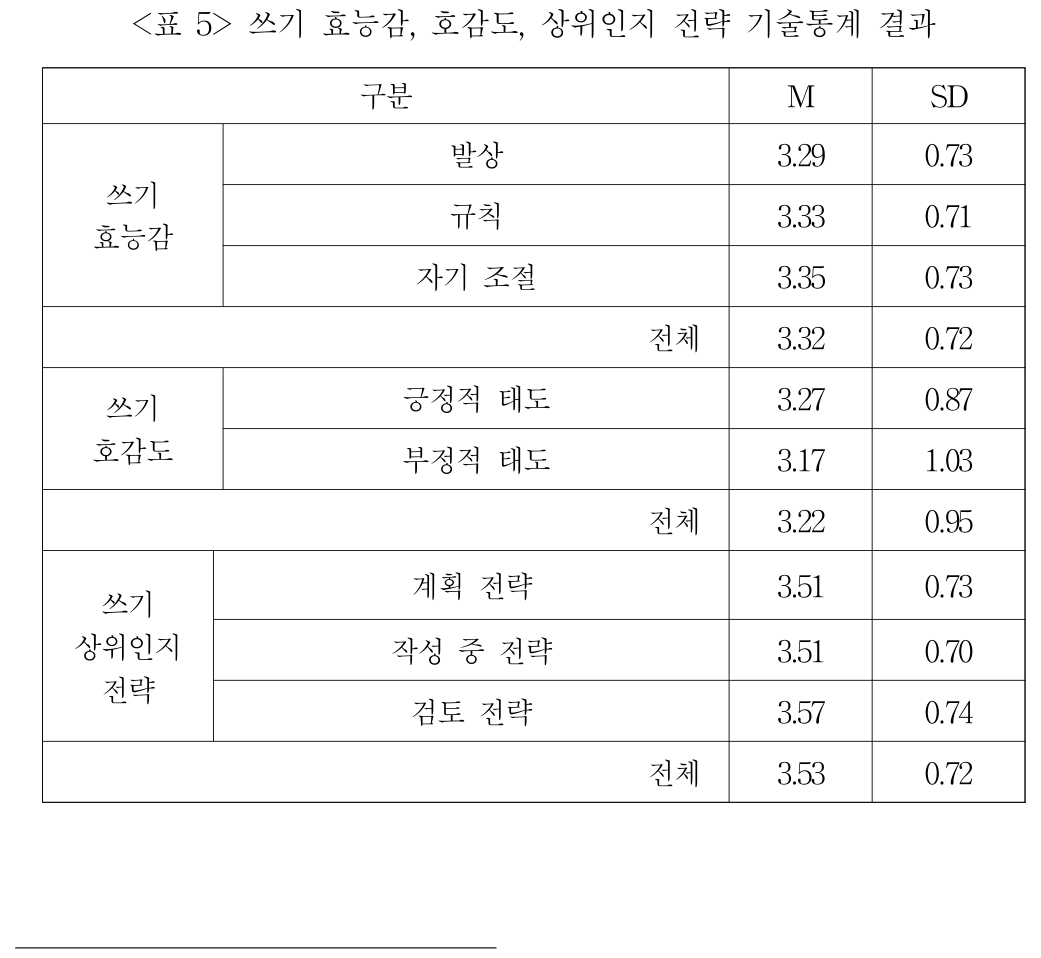

In [5]:
paper5 = {"발상": (3.29, .73), "규칙": (3.33, .71), "자기조절": (3.35, .73), "긍정": (3.27, .87), "부정": (3.17, 1.03),
          "계획": (3.51, .73), "작성": (3.51, .70), "검토": (3.57, .74)}
M = S.mean(axis=0)
SD = np.sqrt(((S - M) ** 2).sum(axis=0) / (N - 1))       # = S.std(axis=0, ddof=1)
rows = [[n, paper5[n][0], round(M[i], 2), paper5[n][1], round(SD[i], 2)] for i, n in enumerate(names)]
# '전체' 행 = 하위 요인 행의 단순 평균
for label, idx, pM, pSD in [("효능감 전체", [0, 1, 2], 3.32, .72), ("호감도 전체", [3, 4], 3.22, .95), ("상위인지 전체", [5, 6, 7], 3.53, .72)]:
    rows.append([label, pM, round(M[idx].mean(), 2), pSD, round(SD[idx].mean(), 2)])
tab5 = pd.DataFrame(rows, columns=["구분", "M (논문)", "M (numpy)", "SD (논문)", "SD (numpy)"])
print(tab5.to_string(index=False))

     구분  M (논문)  M (numpy)  SD (논문)  SD (numpy)
     발상    3.29       3.29     0.73        0.73
     규칙    3.33       3.33     0.71        0.70
   자기조절    3.35       3.35     0.73        0.73
     긍정    3.27       3.27     0.87        0.87
     부정    3.17       3.17     1.03        1.03
     계획    3.51       3.51     0.73        0.73
     작성    3.51       3.51     0.70        0.70
     검토    3.57       3.57     0.74        0.74
 효능감 전체    3.32       3.32     0.72        0.72
 호감도 전체    3.22       3.22     0.95        0.95
상위인지 전체    3.53       3.53     0.72        0.73


## 6. <표 6> 항목별 상위·하위 1순위 문항

문항 하나하나의 평균과 표준편차를 구한 뒤, 척도군(효능감 16문항, 호감도 4문항, 상위인지 31문항) 안에서 평균이 가장 높은 문항과 가장 낮은 문항을 찾는다 — `argmax`, `argmin` 이다.

$$
\bar{x}_j = \frac{1}{N}\sum_i x_{ij}, \qquad s_j = \sqrt{\frac{1}{N-1}\sum_i (x_{ij}-\bar{x}_j)^2}
$$

이 표는 하위 척도 평균만으로는 보이지 않는 **문항 수준의 정보**를 준다. 예컨대 효능감에서 "글을 쓰기 전에 목표를 생각할 수 있다"(15번)는 높고 "독창적인 아이디어를 많이 생각해 낼 수 있다"(4번)는 낮다는 사실이 논문의 교육적 제언(발상 단계의 아이디어 생성 활동 강화)으로 연결된다.

> 참고: 논문의 26번 문항 SD 0.40 은 1~5 정수 응답에서 평균 3.76 일 때 도달 가능한 최소 SD(≈0.43)보다 작아 정수 자료로는 재현이 불가능하다. 시뮬레이션은 최소값에 맞추었다.

**논문 원문 캡처** — <표 6> 항목별 상위, 하위 1순위 문항

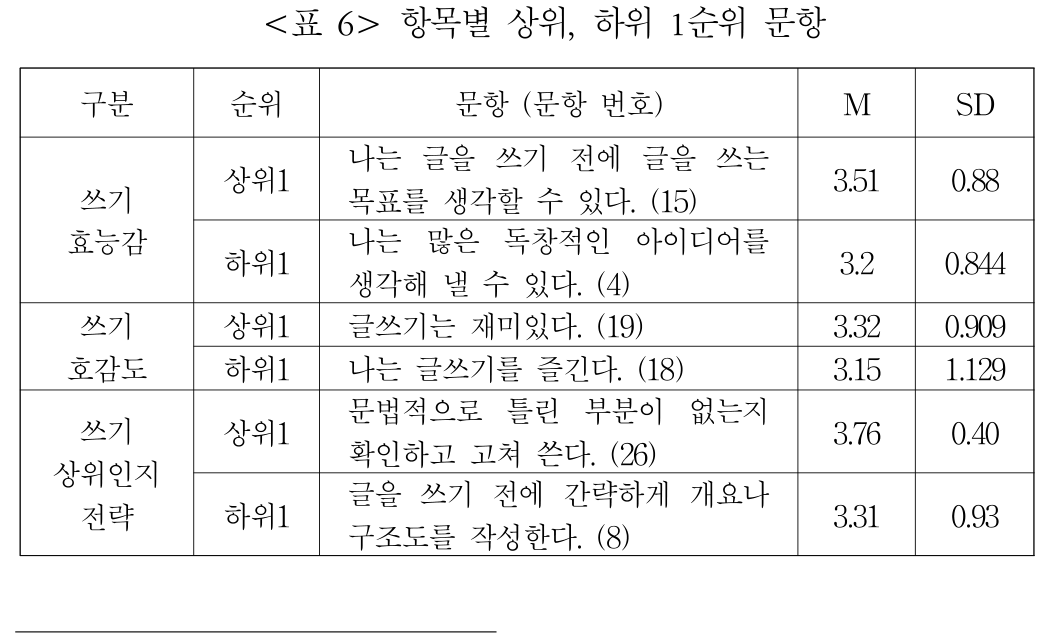

In [6]:
paper6 = {"SE15": (3.51, .880), "SE04": (3.20, .844), "LW19": (3.32, .909), "LW18": (3.15, 1.129), "MC26": (3.76, .400), "MC08": (3.31, .930)}
item_cols = [c for c in df.columns if c[:2] in ("SE", "LW", "MC")]
Xi = df[item_cols].to_numpy(dtype=float)
im = Xi.mean(axis=0)
isd = np.sqrt(((Xi - im) ** 2).sum(axis=0) / (N - 1))
rows = []
for grp, gname in [("SE", "쓰기 효능감"), ("LW", "쓰기 호감도"), ("MC", "쓰기 상위인지 전략")]:
    idx = np.array([i for i, c in enumerate(item_cols) if c.startswith(grp)])
    for rank, j in [("상위1", idx[np.argmax(im[idx])]), ("하위1", idx[np.argmin(im[idx])])]:
        c = item_cols[j]
        pm, ps = paper6.get(c, (None, None))
        rows.append([gname, rank, c, pm, round(im[j], 2), ps, round(isd[j], 3)])
tab6 = pd.DataFrame(rows, columns=["구분", "순위", "문항", "M (논문)", "M (numpy)", "SD (논문)", "SD (numpy)"])
print(tab6.to_string(index=False))

        구분  순위   문항  M (논문)  M (numpy)  SD (논문)  SD (numpy)
    쓰기 효능감 상위1 SE15    3.51       3.51    0.880       0.882
    쓰기 효능감 하위1 SE04    3.20       3.20    0.844       0.844
    쓰기 호감도 상위1 LW19    3.32       3.32    0.909       0.916
    쓰기 호감도 하위1 LW18    3.15       3.15    1.129       1.133
쓰기 상위인지 전략 상위1 MC26    3.76       3.77    0.400       0.424
쓰기 상위인지 전략 하위1 MC08    3.31       3.31    0.930       0.927


## 7. <표 7> 하위 척도 간 피어슨 상관과 유의성 검정

**상관계수**. 열을 중심화·표준화한 행렬 $Z$ (각 열 평균 0, 분산 1)를 만들면 상관행렬은 행렬곱 하나로 나온다:

$$
r_{ab} = \frac{\sum_i (S_{ia}-M_a)(S_{ib}-M_b)}{\sqrt{\sum_i (S_{ia}-M_a)^2}\sqrt{\sum_i (S_{ib}-M_b)^2}}
\quad\Longleftrightarrow\quad
R = \frac{Z^\top Z}{N-1}
$$

**유의성 검정**. "모집단 상관 $\rho = 0$" 이라는 귀무가설 아래서

$$
t = \frac{r\sqrt{N-2}}{\sqrt{1-r^2}} \sim t_{N-2}, \qquad p = 2\,P\!\left(T_{N-2} > |t|\right)
$$

- $p$ 는 "상관이 실제로 0 인 모집단에서 172명을 뽑았을 때 지금처럼 크거나 더 큰 $|r|$ 이 우연히 나올 확률"이다. 논문의 별표는 $*p<.05$, $**p<.001$ 을 뜻한다.
- $N=172$ 면 $|r| \ge 0.15$ 정도부터 $p<.05$, $|r| \ge 0.25$ 정도부터 $p<.001$ 이 된다. 그래서 표의 모든 상관이 $**$ 인데, 이는 "관계가 강하다"가 아니라 "0 이 아니라고 말할 근거가 충분하다"는 뜻일 뿐이다. 관계의 **크기**는 $r$ 자체(.858 처럼)로 읽어야 한다.
- 논문은 부정적 태도만 다른 모든 변수와 **음(−)** 의 상관을 보인다는 점, 그리고 작성 중 전략–계획 전략(.856), 발상–규칙(.858) 처럼 .8 이 넘는 높은 상관이 있다는 점을 해석의 근거로 삼는다. 상관이 .8 을 넘는 변수들을 한 회귀식에 함께 넣으면 9절에서 보는 **다중공선성** 문제가 생긴다.

**논문 원문 캡처** — <표 7> 쓰기 효능감과 쓰기 상위인지 전략 간의 상관관계

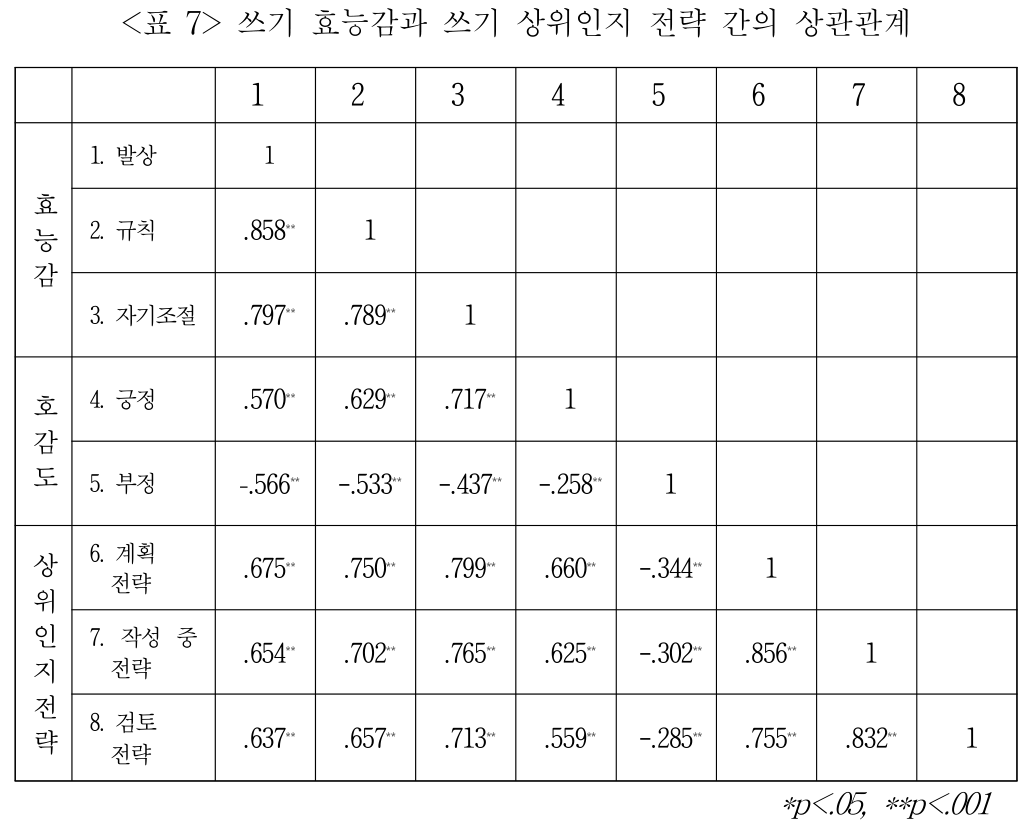

In [7]:
paper7 = np.array([
    [1.000, 0.858, 0.797, 0.570, -0.566, 0.675, 0.654, 0.637],
    [0.858, 1.000, 0.789, 0.629, -0.533, 0.750, 0.702, 0.657],
    [0.797, 0.789, 1.000, 0.717, -0.437, 0.799, 0.765, 0.713],
    [0.570, 0.629, 0.717, 1.000, -0.258, 0.660, 0.625, 0.559],
    [-0.566, -0.533, -0.437, -0.258, 1.000, -0.344, -0.302, -0.285],
    [0.675, 0.750, 0.799, 0.660, -0.344, 1.000, 0.856, 0.755],
    [0.654, 0.702, 0.765, 0.625, -0.302, 0.856, 1.000, 0.832],
    [0.637, 0.657, 0.713, 0.559, -0.285, 0.755, 0.832, 1.000],
])
Z = (S - M) / SD                       # 열 표준화
R = Z.T @ Z / (N - 1)                  # 상관행렬
T = R * np.sqrt(N - 2) / np.sqrt(1 - R ** 2 + np.eye(8))     # t 통계량 (대각선은 무시)
P = 2 * stats.t.sf(np.abs(T), df=N - 2)                        # 양측 p-값

def star(p): return "**" if p < .001 else ("*" if p < .05 else "")
print("하삼각: numpy r (별표 = 유의수준) / 논문 r\n")
print(" " * 10 + "".join(f"{n:>14s}" for n in names[:-1]))
for a in range(8):
    line = f"{a+1}. {names[a]:<6s}"
    for b in range(a):
        line += f"{R[a,b]:+.3f}{star(P[a,b]):<2s}/{paper7[a,b]:+.3f} "
    print(line)
iu = np.triu_indices(8, 1)
print(f"\n최대 절대 오차 = {np.abs(R[iu]-paper7[iu]).max():.3f},  평균 절대 오차 = {np.abs(R[iu]-paper7[iu]).mean():.3f}")
print(f"모든 상관이 p<.001 (논문의 **) 인가?  {bool((P[iu] < .001).all())}")
print(f"\n예시: 발상-규칙  r = {R[0,1]:.3f},  t = {T[0,1]:.2f},  p = {P[0,1]:.1e}")
print(f"참고: N=172 에서 p<.05 가 되는 최소 |r| = {stats.t.ppf(.975, N-2)/np.sqrt(N-2+stats.t.ppf(.975, N-2)**2):.3f},  p<.001 최소 |r| = {stats.t.ppf(.9995, N-2)/np.sqrt(N-2+stats.t.ppf(.9995, N-2)**2):.3f}")

하삼각: numpy r (별표 = 유의수준) / 논문 r

                      발상            규칙          자기조절            긍정            부정            계획            작성
1. 발상    
2. 규칙    +0.840**/+0.858 
3. 자기조절  +0.787**/+0.797 +0.787**/+0.789 
4. 긍정    +0.565**/+0.570 +0.629**/+0.629 +0.715**/+0.717 
5. 부정    -0.566**/-0.566 -0.532**/-0.533 -0.440**/-0.437 -0.257**/-0.258 
6. 계획    +0.674**/+0.675 +0.730**/+0.750 +0.784**/+0.799 +0.658**/+0.660 -0.345**/-0.344 
7. 작성    +0.644**/+0.654 +0.704**/+0.702 +0.764**/+0.765 +0.626**/+0.625 -0.308**/-0.302 +0.841**/+0.856 
8. 검토    +0.627**/+0.637 +0.655**/+0.657 +0.714**/+0.713 +0.560**/+0.559 -0.293**/-0.285 +0.742**/+0.755 +0.833**/+0.832 

최대 절대 오차 = 0.020,  평균 절대 오차 = 0.005
모든 상관이 p<.001 (논문의 **) 인가?  True

예시: 발상-규칙  r = 0.840,  t = 20.20,  p = 4.9e-47
참고: N=172 에서 p<.05 가 되는 최소 |r| = 0.150,  p<.001 최소 |r| = 0.249


### 7-1. 산포도로 상관계수 읽기 — 네 쌍의 비교

상관계수 $r$ 은 산포도의 **모양**을 숫자 하나로 요약한 것이다. 두 변수를 각각 표준화하면 점구름은 대략 타원이 되고, 그 타원의 **기울기 방향이 $r$ 의 부호**, **폭이 $|r|$ 의 크기**를 말한다. 정규분포 근사에서 타원의 짧은 축과 긴 축의 비는

$$
\frac{\text{짧은 축}}{\text{긴 축}} = \sqrt{\frac{1-|r|}{1+|r|}}
$$

이므로 $r=.84$ 면 0.29(가늘고 긴 띠), $r=.57$ 이면 0.53, $r=.29$ 면 0.74(거의 둥근 구름)다. 아래 네 쌍은 <표 7> 에서 상관의 크기와 부호가 서로 다른 조합을 고른 것이다.

| 쌍 | 논문 r | 보고 싶은 것 |
|---|---|---|
| 효능감 발상 – 효능감 규칙 | .858 | 강한 양의 상관: 좁고 긴 띠, 오른쪽 위로 |
| 효능감 발상 – 호감도 부정 | −.566 | 중간 크기의 음의 상관: 왼쪽 위 → 오른쪽 아래로 기울어진 넓은 타원 |
| 검토 전략 – 호감도 부정 | −.285 | 약한 음의 상관: 기울기가 있는 듯 없는 듯한 둥근 구름 |
| 계획 전략 – 자기조절 | .799 | 서로 다른 척도군(전략 vs 효능감) 사이의 강한 양의 상관 |

각 그림에는 최소제곱 회귀직선 $\hat y = a + b x$ ($b = r\,s_y/s_x$) 과 **평균 중심의 ±1 SD 타원**을 함께 그린다. 하위 척도 점수는 문항 평균이라 값이 겹치는 자리가 많으므로 약간의 jitter 를 준다(값 자체는 바뀌지 않는다).

산포도를 보며 확인할 것 세 가지: (1) $|r|$ 이 클수록 점들이 직선 근처에 얼마나 붙는가, (2) $r$ 이 같은 크기라도 부호에 따라 기울기 방향이 반대인가, (3) $r=-.29$ 처럼 약한 상관도 $N=172$ 에서는 $p<.001$ 로 유의하다는 사실이 그림의 인상과 어떻게 다른가 — "유의하다"와 "관계가 뚜렷하다"는 다른 말이다.

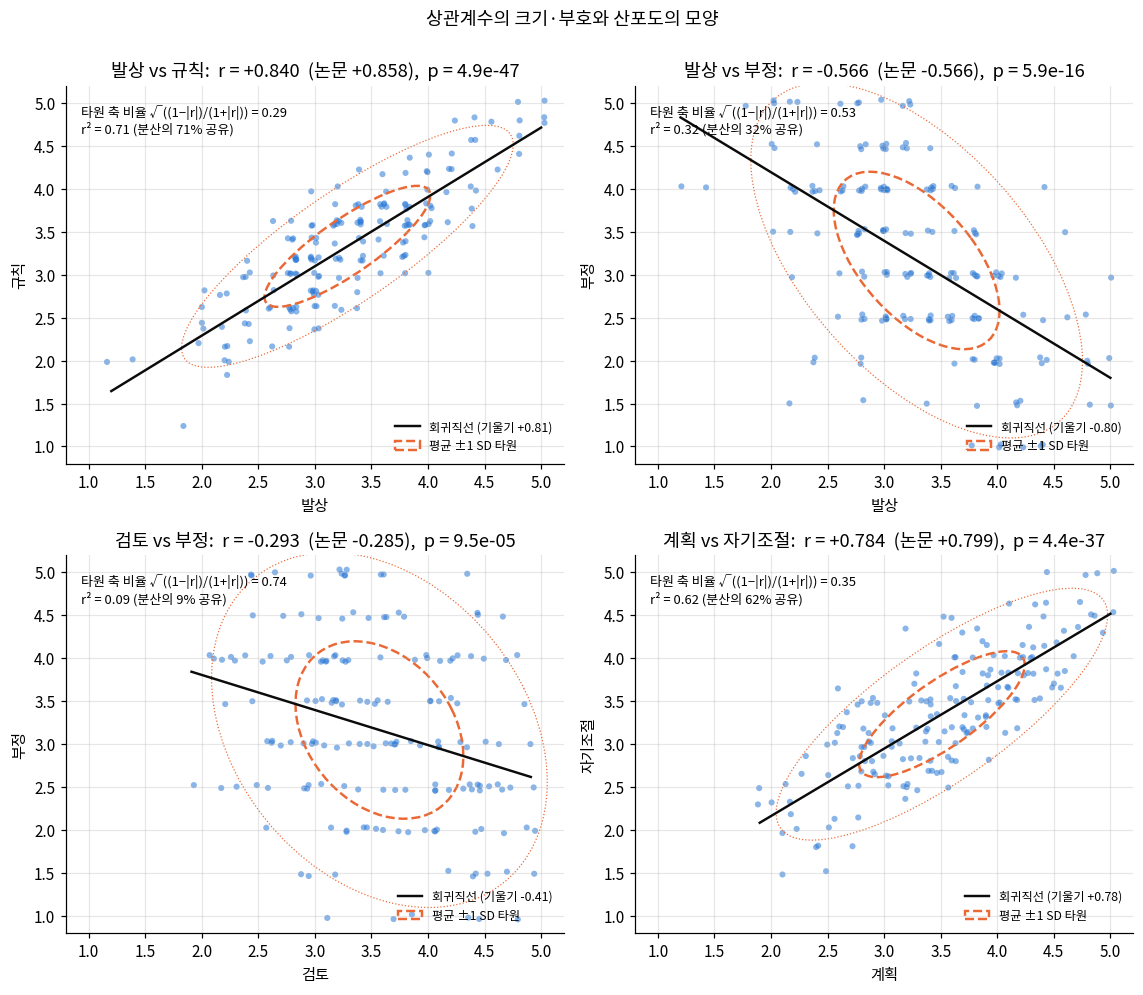

In [8]:
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.patches import Ellipse
_avail = {f.name for f in font_manager.fontManager.ttflist}
_kor = next((f for f in ["AppleGothic", "Apple SD Gothic Neo", "Malgun Gothic", "NanumGothic", "Noto Sans CJK KR", "Noto Sans CJK JP"] if f in _avail),
            next((f for f in sorted(_avail) if "CJK" in f or "Gothic" in f), "DejaVu Sans"))
plt.rcParams.update({"font.family": _kor, "axes.unicode_minus": False, "figure.dpi": 110})

def sd_ellipse(ax, x, y, n_sd=1.0, **kw):
    # 공분산행렬의 고유벡터/고윳값으로 ±n_sd 타원을 그린다
    cov = np.cov(x, y); vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]; vals, vecs = vals[order], vecs[:, order]
    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    w, h = 2 * n_sd * np.sqrt(vals)
    ax.add_patch(Ellipse((x.mean(), y.mean()), w, h, angle=angle, fill=False, **kw))

pairs = [("발상", "규칙", .858), ("발상", "부정", -.566), ("검토", "부정", -.285), ("계획", "자기조절", .799)]
rng = np.random.default_rng(7)
fig, axes = plt.subplots(2, 2, figsize=(10.5, 9))
for ax, (a, b, r_paper) in zip(axes.ravel(), pairs):
    x, y = S[:, names.index(a)], S[:, names.index(b)]
    r = np.corrcoef(x, y)[0, 1]
    t = r * np.sqrt(N - 2) / np.sqrt(1 - r ** 2); p = 2 * stats.t.sf(abs(t), N - 2)
    slope = r * y.std(ddof=1) / x.std(ddof=1); intercept = y.mean() - slope * x.mean()
    jx, jy = rng.uniform(-.04, .04, N), rng.uniform(-.04, .04, N)
    ax.scatter(x + jx, y + jy, s=16, color="#2a78d6", alpha=.55, edgecolor="none")
    gx = np.array([x.min(), x.max()]); ax.plot(gx, intercept + slope * gx, color="#0b0b0b", lw=1.6, label=f"회귀직선 (기울기 {slope:+.2f})")
    sd_ellipse(ax, x, y, 1.0, color="#eb6834", lw=1.6, ls="--", label="평균 ±1 SD 타원")
    sd_ellipse(ax, x, y, 2.0, color="#eb6834", lw=.8, ls=":")
    ratio = np.sqrt((1 - abs(r)) / (1 + abs(r)))
    ax.set(title=f"{a} vs {b}:  r = {r:+.3f}  (논문 {r_paper:+.3f}),  p = {p:.1e}", xlabel=a, ylabel=b, xlim=(0.8, 5.2), ylim=(0.8, 5.2))
    ax.text(.03, .95, f"타원 축 비율 √((1−|r|)/(1+|r|)) = {ratio:.2f}\nr² = {r**2:.2f} (분산의 {100*r**2:.0f}% 공유)", transform=ax.transAxes, fontsize=8.5, va="top")
    ax.legend(frameon=False, fontsize=8, loc="lower right"); ax.grid(alpha=.3); ax.spines[["top", "right"]].set_visible(False)
plt.suptitle("상관계수의 크기·부호와 산포도의 모양", y=1.0); plt.tight_layout(); plt.show()

**읽기.** 발상–규칙(r = .84)은 ±1 SD 타원이 가늘고 길어 한 변수를 알면 다른 변수를 꽤 정확히 맞출 수 있다($r^2 = .71$, 분산의 71 %를 공유). 발상–부정(r = −.57)은 방향이 반대이고 타원이 두 배 가까이 뚱뚱하다 — 효능감이 높은 사람이 부정적 태도가 낮은 경향은 뚜렷하지만 예외도 많다. 검토–부정(r = −.29)은 회귀직선이 살짝 기울어 있을 뿐 구름은 거의 둥글다; 분산의 8 %만 공유하는데도 $p<.001$ 인 것은 $N=172$ 가 크기 때문이다. 계획–자기조절(r = .78)은 서로 다른 척도군 사이인데도 발상–규칙과 비슷한 모양이며, 논문이 "자기조절이 쓰기 과정 관리의 핵심"이라고 해석한 근거다.

## 8-0. F-검정에 앞서 — 두 집단만 비교하는 t-검정

세 집단 이상을 비교하는 분산분석(다음 절)은 **두 집단 비교(t-검정)의 일반화**다. 먼저 초급(33명)과 고급(36명)의 부정적 호감도만 놓고 t-검정의 논리를 익힌 뒤, 그것이 F 와 어떻게 이어지는지 본다.

### 8-0-1. 독립표본 t-검정의 계산

두 집단의 평균 $\bar y_1, \bar y_2$, 표본분산 $s_1^2, s_2^2$, 크기 $n_1, n_2$ 에 대해 (등분산 가정, Student's t)

$$
t = \frac{\bar y_2 - \bar y_1}{SE}, \qquad
SE = s_p\sqrt{\frac{1}{n_1}+\frac{1}{n_2}}, \qquad
s_p^2 = \frac{(n_1-1)s_1^2+(n_2-1)s_2^2}{n_1+n_2-2}, \qquad df = n_1+n_2-2
$$

- **분자**는 관심 있는 양, 즉 평균 차이다. **분모 $SE$** 는 "두 집단이 같은 모집단에서 왔다면 표본 평균 차이가 우연히 이만큼 흔들린다"는 크기다. $s_p$ 는 두 집단의 개인차를 합친(pooled) 표준편차, $\sqrt{1/n_1+1/n_2}$ 는 표본이 클수록 평균이 안정된다는 사실을 반영한다.
- 따라서 $t$ 는 **"관측된 차이가 우연한 흔들림의 몇 배인가"**다. $|t|$ 가 2 를 넘으면 대략 $p<.05$ 다.
- 분산이 다를 때는 Welch 의 t(분모에 $\sqrt{s_1^2/n_1+s_2^2/n_2}$, 보정된 $df$)를 쓴다. 두 집단의 SD 가 1.04 와 0.87 로 비슷하므로 여기서는 두 결과가 거의 같다.

### 8-0-2. t 와 F 의 관계

집단이 **둘**일 때 분산분석의 $F$ 는 정확히 $t^2$ 이고 p-값도 같다. 즉 t-검정은 F-검정의 특수한 경우이며, F-검정은 "여러 집단의 평균 차이를 하나의 통계량으로" 묶은 것이다. 아래에서 초급·고급 두 집단으로 $F$ 를 계산해 $t^2$ 과 같음을 확인한다.

### 8-0-3. 그러면 세 집단 중 두 집단만 골라 t-검정을 해도 되는가?

**연구 질문이 처음부터 "초급 vs 고급"이었다면** 된다. 그러나 **세 집단의 평균을 본 뒤 가장 벌어진 두 집단을 골라** t-검정을 하면 문제가 생긴다. 급수가 무관한 세상에서도 세 집단 중 가장 높은 것과 가장 낮은 것은 우연히 벌어져 있기 마련이라, "최대–최소 쌍"만 골라 검정하면 5 % 수준에서 검정해도 실제 1종 오류율이 10 %를 넘는다. 이것이 **다중비교 문제**이고, 논문이 ANOVA 로 "전체적으로 차이가 있는가"를 먼저 묻고 Scheffé 사후검정으로 쌍을 보는 이유다. 아래에서 라벨 섞기로 이 오류율 부풀림을 직접 측정한다.

In [9]:
y_all = S[:, names.index("부정")]; g_all = df["topik"].to_numpy()
y1, y2 = y_all[g_all == 1], y_all[g_all == 3]                      # 초급, 고급
n1, n2 = len(y1), len(y2)
m1, m2 = y1.mean(), y2.mean(); v1, v2 = y1.var(ddof=1), y2.var(ddof=1)
sp = np.sqrt(((n1 - 1) * v1 + (n2 - 1) * v2) / (n1 + n2 - 2))
SE = sp * np.sqrt(1 / n1 + 1 / n2)
t_stat = (m2 - m1) / SE; df_t = n1 + n2 - 2
p_t = 2 * stats.t.sf(abs(t_stat), df_t)
print(f"초급: n={n1}, M={m1:.3f}, SD={np.sqrt(v1):.3f}    고급: n={n2}, M={m2:.3f}, SD={np.sqrt(v2):.3f}")
print(f"평균 차이 = {m2 - m1:+.3f},  s_p = {sp:.3f},  SE = {SE:.3f}")
print(f"t = {m2 - m1:+.3f} / {SE:.3f} = {t_stat:.3f},  df = {df_t},  p = {p_t:.2e}   (numpy 수식)")
print(f"scipy ttest_ind (등분산):  t = {stats.ttest_ind(y2, y1)[0]:.3f}, p = {stats.ttest_ind(y2, y1)[1]:.2e}")
tw, pw = stats.ttest_ind(y2, y1, equal_var=False)
print(f"scipy ttest_ind (Welch):   t = {tw:.3f}, p = {pw:.2e}")
ci = (m2 - m1) + np.array([-1, 1]) * stats.t.ppf(.975, df_t) * SE
print(f"평균 차이의 95% 신뢰구간 = [{ci[0]:+.3f}, {ci[1]:+.3f}]")

# 두 집단 F 와 t² 의 관계
y12 = np.concatenate([y1, y2]); g12 = np.array([0] * n1 + [1] * n2); grand = y12.mean()
SSB2 = n1 * (m1 - grand) ** 2 + n2 * (m2 - grand) ** 2
SSW2 = ((y1 - m1) ** 2).sum() + ((y2 - m2) ** 2).sum()
F2 = (SSB2 / 1) / (SSW2 / (n1 + n2 - 2))
print(f"\n두 집단 ANOVA:  F = {F2:.3f},  t² = {t_stat**2:.3f}  → 같다.  p(F) = {stats.f.sf(F2, 1, df_t):.2e} = p(t)")

초급: n=33, M=2.576, SD=1.039    고급: n=36, M=3.778, SD=0.866
평균 차이 = +1.202,  s_p = 0.952,  SE = 0.230
t = +1.202 / 0.230 = 5.237,  df = 67,  p = 1.78e-06   (numpy 수식)
scipy ttest_ind (등분산):  t = 5.237, p = 1.78e-06
scipy ttest_ind (Welch):   t = 5.195, p = 2.38e-06
평균 차이의 95% 신뢰구간 = [+0.744, +1.660]

두 집단 ANOVA:  F = 27.421,  t² = 27.421  → 같다.  p(F) = 1.78e-06 = p(t)


In [10]:
# 다중비교 문제: 급수가 무관한 세상(라벨 섞기)에서 (a) 미리 정한 쌍 vs (b) 사후에 가장 벌어진 쌍을 t-검정하면?
mask3 = g_all > 0; y3 = y_all[mask3]; g3 = g_all[mask3]
rng = np.random.default_rng(11); B = 5000
sig_fixed = sig_maxpair = 0
for _ in range(B):
    gp = rng.permutation(g3)
    means = {l: y3[gp == l].mean() for l in (1, 2, 3)}
    lo, hi = min(means, key=means.get), max(means, key=means.get)
    sig_fixed   += stats.ttest_ind(y3[gp == 3], y3[gp == 1])[1] < .05          # 미리 정한 쌍 (초급 vs 고급)
    sig_maxpair += stats.ttest_ind(y3[gp == hi], y3[gp == lo])[1] < .05        # 결과를 보고 고른 최대-최소 쌍
print(f"급수가 무관한 세상(라벨 섞기 {B}회)에서 p < .05 가 나온 비율")
print(f"  (a) 미리 정한 쌍(초급 vs 고급)을 검정:            {sig_fixed / B:.3f}   ← 명목 5% 와 일치")
print(f"  (b) 세 평균을 본 뒤 가장 벌어진 쌍을 골라 검정:   {sig_maxpair / B:.3f}   ← 5% 의 두 배 이상 (1종 오류 부풀림)")
print("→ 사후에 쌍을 고르려면 ANOVA + 사후검정(Scheffé 등)처럼 다중비교를 보정해야 한다.")

급수가 무관한 세상(라벨 섞기 5000회)에서 p < .05 가 나온 비율
  (a) 미리 정한 쌍(초급 vs 고급)을 검정:            0.049   ← 명목 5% 와 일치
  (b) 세 평균을 본 뒤 가장 벌어진 쌍을 골라 검정:   0.119   ← 5% 의 두 배 이상 (1종 오류 부풀림)
→ 사후에 쌍을 고르려면 ANOVA + 사후검정(Scheffé 등)처럼 다중비교를 보정해야 한다.


**정리.** t-검정은 "평균 차이 ÷ 우연한 흔들림"이라는 한 줄 논리로 두 집단을 비교하며, 집단이 둘일 때 $F=t^2$ 이므로 분산분석과 같은 결론을 준다. 초급 vs 고급을 t-검정하는 것은 그 비교가 **사전에 정해진 질문**일 때 적절하고, 세 집단을 보고 나서 가장 벌어진 쌍을 고른 것이라면 1종 오류율이 부풀어 부적절하다 — 그때는 다음 절의 ANOVA 와 Scheffé 사후검정이 답이다. 학습 순서로는 t(두 집단, 차이/SE) → F(여러 집단, 집단 간 분산/집단 내 분산) → 사후검정(어느 쌍인가) 이 자연스럽다.

## 8. <표 8>, <표 9> 한국어 수준(TOPIK)에 따른 일원분산분석(One-way ANOVA)

TOPIK 급수가 있는 학습자(초급 33, 중급 51, 고급 36; '없음' 52명은 제외)를 세 집단으로 나누어, 하위 척도 평균이 집단에 따라 다른지 검정한다.

**분산의 분해**. 전체 변동을 "집단 간" 과 "집단 내" 로 나눈다 ($k=3$ 집단, 총 $n=120$ 명, 집단 $g$ 의 크기 $n_g$, 평균 $\bar{y}_g$, 전체 평균 $\bar{y}$):

$$
SS_B = \sum_g n_g(\bar{y}_g-\bar{y})^2, \qquad
SS_W = \sum_g \sum_{i\in g}(y_{i}-\bar{y}_g)^2, \qquad
F = \frac{SS_B/(k-1)}{SS_W/(n-k)} \sim F_{k-1,\;n-k}
$$

- **직관**: 분자는 "집단 평균들이 서로 얼마나 떨어져 있나", 분모는 "같은 집단 안에서도 개인들이 원래 얼마나 흩어져 있나"다. 집단 차이가 개인차의 잡음에 비해 클수록 $F$ 가 커진다. $F \approx 1$ 이면 집단 차이가 잡음 수준이라는 뜻이다.
- **p-값**: 세 집단의 모평균이 모두 같다는 귀무가설 아래서 지금의 $F$ 이상이 나올 확률. 논문에서 유의한 것은 부정적 호감도($F=14.918, p<.001$)와 검토 전략($F=3.506, p=.017$)뿐이다.
- **Scheffé 사후검정**: $F$ 가 유의해도 "어느 집단끼리" 다른지는 알려주지 않으므로, 모든 쌍 $(g,h)$ 에 대해
  $$F_{gh} = \frac{(\bar{y}_g-\bar{y}_h)^2}{MS_W\left(\frac{1}{n_g}+\frac{1}{n_h}\right)}, \qquad \text{유의 조건: } F_{gh} > (k-1)\,F_{\alpha;\,k-1,\,n-k}$$
  를 본다. 임계값에 $(k-1)$ 을 곱해 여러 쌍을 동시에 비교할 때 생기는 1종 오류 증가를 보수적으로 막는 방법이다. 논문은 "초·중급 < 고급" 으로 보고했다.

> **시뮬레이션 자료와 논문 표의 관계**: 생성 스크립트는 급수별 **평균과 SD 모두**를 논문 값으로 보정하므로, 발상·규칙·자기조절·부정 호감도·계획·작성의 여섯 요인은 급수별 M·SD 가 ±0.01 이내로 일치하고 $F$ 도 논문과 같은 결론을 준다(계획 전략의 논문 $F=1.524$ 는 표에 적힌 M·SD 로부터 계산하면 $F\approx0.3$ 이 나와 논문 값 자체가 내부적으로 맞지 않는다). 긍정 호감도와 검토 전략은 논문의 급수별 M·SD 가 <표 5> 의 전체 M·SD 와 **산술적으로 양립하지 않는다** — 세 급수 집단의 집단 내 분산과 집단 간 분산만 더해도 전체 SD 가 각각 0.92, 0.95 이상이 되어 표 5 의 0.87, 0.74 를 넘는다('없음' 집단의 분산이 0 이어도). 기본 데이터(`survey_data.csv`)는 표 5 를 우선해 이 두 요인의 집단 차이를 35 % 로 축소했다(`GROUP_SHRINK`). 반대로 `python generate_survey_data.py --priority table89` 로 만든 `survey_data_table89.csv` 는 이 두 요인의 급수별 M·SD 와 검토 전략의 $F$(3.7 vs 논문 3.5)를 논문대로 맞추는 대신 표 5 의 전체 SD 가 어긋난다(긍정 .94, 검토 .97). 두 파일을 바꿔 실행해 보면 "어느 표를 믿을 것인가"가 결과를 어떻게 바꾸는지 확인할 수 있다.

**논문 원문 캡처** — <표 8> 한국어 수준에 따른 쓰기 효능감, 호감도 결과

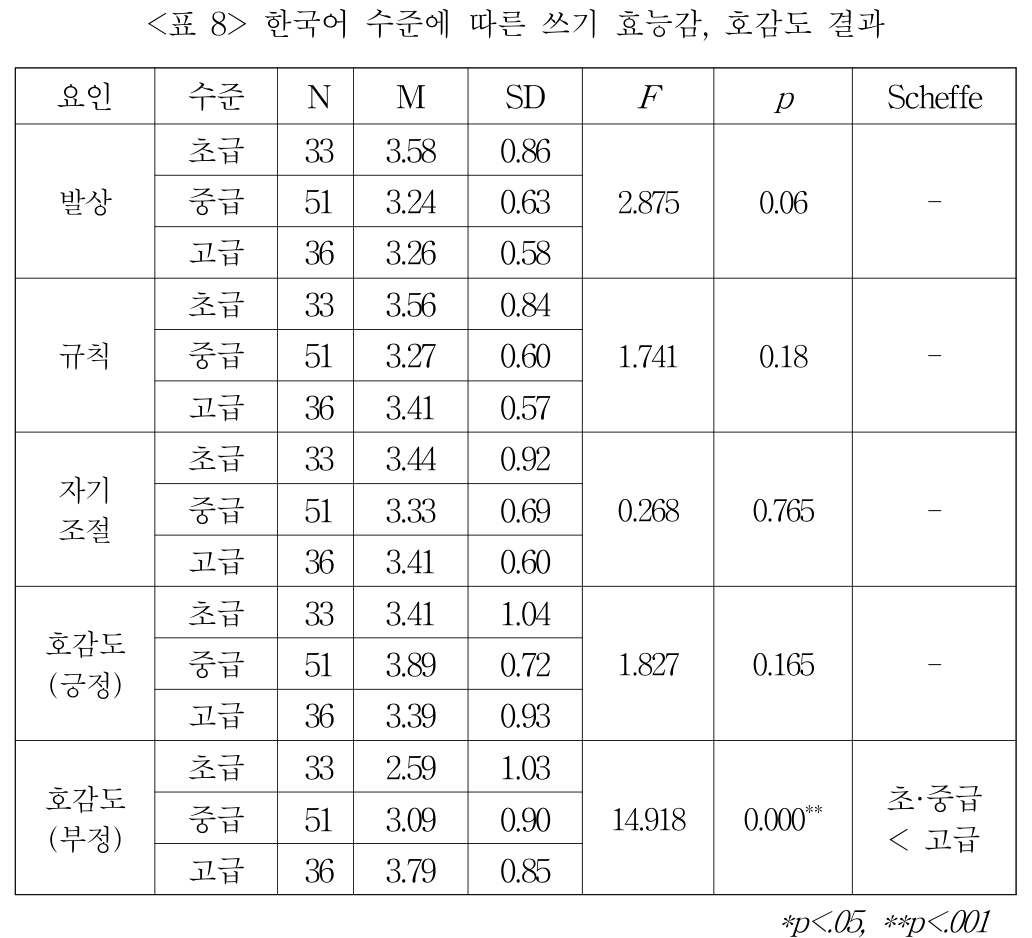

<표 9> 도 같은 절차다 (계획·작성·검토 전략).

**논문 원문 캡처** — <표 9> 한국어 수준에 따른 쓰기 상위인지 전략 결과

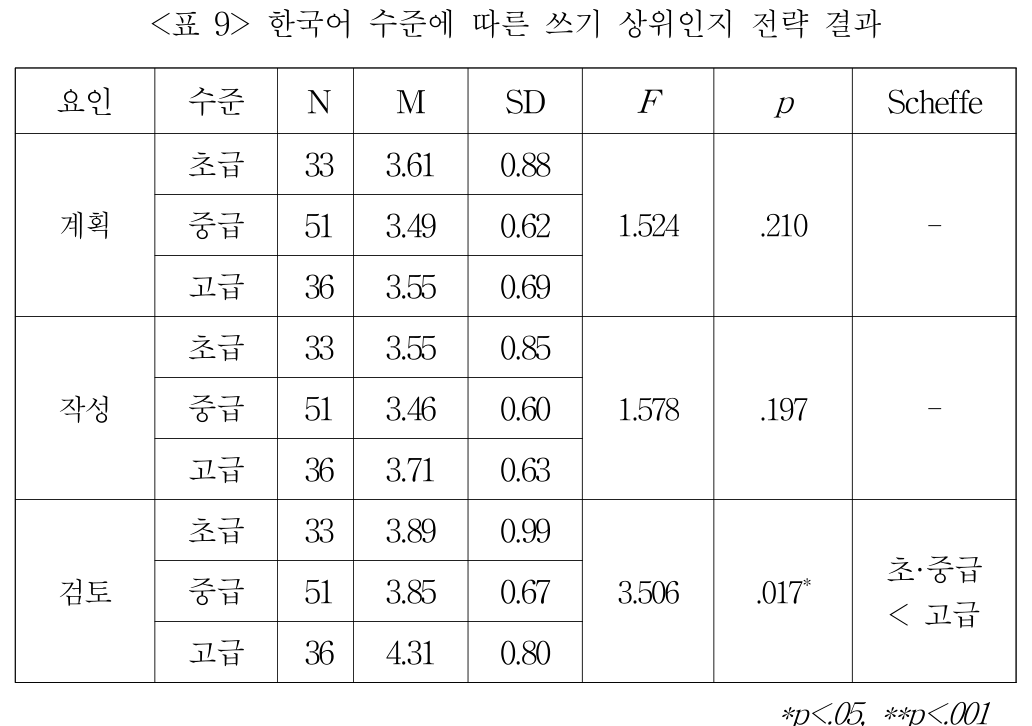

In [11]:
def one_way_anova(y, g):
    # y: 관측값, g: 집단 라벨 (같은 길이)
    levels = np.unique(g)
    k, n = len(levels), len(y)
    grand = y.mean()
    ng = np.array([(g == l).sum() for l in levels])
    mg = np.array([y[g == l].mean() for l in levels])
    sdg = np.array([y[g == l].std(ddof=1) for l in levels])
    SSB = (ng * (mg - grand) ** 2).sum()
    SSW = sum(((y[g == l] - y[g == l].mean()) ** 2).sum() for l in levels)
    dfB, dfW = k - 1, n - k
    MSB, MSW = SSB / dfB, SSW / dfW
    F = MSB / MSW
    p = stats.f.sf(F, dfB, dfW)
    # Scheffé 사후검정
    Fcrit = (k - 1) * stats.f.ppf(.95, dfB, dfW)
    sig_pairs = []
    for a in range(k):
        for b in range(a + 1, k):
            Fab = (mg[a] - mg[b]) ** 2 / (MSW * (1 / ng[a] + 1 / ng[b]))
            if Fab > Fcrit:
                lo, hi = (a, b) if mg[a] < mg[b] else (b, a)
                sig_pairs.append(f"{levels[lo]}<{levels[hi]}")
    return dict(n=ng, M=mg, SD=sdg, F=F, p=p, scheffe=", ".join(sig_pairs) if sig_pairs else "-")

paper89 = {  # (초급 M, SD), (중급 M, SD), (고급 M, SD), F, p, Scheffé
    "발상":     [(3.58, .86), (3.24, .63), (3.26, .58), 2.875, .060, "-"],
    "규칙":     [(3.56, .84), (3.27, .60), (3.41, .57), 1.741, .180, "-"],
    "자기조절": [(3.44, .92), (3.33, .69), (3.41, .60), 0.268, .765, "-"],
    "긍정":     [(3.41, 1.04), (3.89, .72), (3.39, .93), 1.827, .165, "-"],
    "부정":     [(2.59, 1.03), (3.09, .90), (3.79, .85), 14.918, .000, "초·중급<고급"],
    "계획":     [(3.61, .88), (3.49, .62), (3.55, .69), 1.524, .210, "-"],
    "작성":     [(3.55, .85), (3.46, .60), (3.71, .63), 1.578, .197, "-"],
    "검토":     [(3.89, .99), (3.85, .67), (4.31, .80), 3.506, .017, "초·중급<고급"],
}
lvl = {1: "초급", 2: "중급", 3: "고급"}
mask = df["topik"].to_numpy() > 0                       # TOPIK '없음' 제외
g = np.array([lvl[v] for v in df["topik"].to_numpy()[mask]])

rows = []
for i, n in enumerate(names):
    r = one_way_anova(S[mask, i], g)
    pp = paper89[n]
    for j, L in enumerate(["초급", "중급", "고급"]):
        jj = list(np.unique(g)).index(L)
        rows.append([n, L, int(r["n"][jj]), pp[j][0], round(r["M"][jj], 2), pp[j][1], round(r["SD"][jj], 2),
                     pp[3] if j == 0 else "", round(r["F"], 3) if j == 0 else "",
                     pp[4] if j == 0 else "", round(r["p"], 3) if j == 0 else "",
                     pp[5] if j == 0 else "", r["scheffe"] if j == 0 else ""])
tab89 = pd.DataFrame(rows, columns=["요인", "수준", "N", "M(논문)", "M(numpy)", "SD(논문)", "SD(numpy)", "F(논문)", "F(numpy)", "p(논문)", "p(numpy)", "Scheffé(논문)", "Scheffé(numpy)"])
print(tab89.to_string(index=False))

  요인 수준  N  M(논문)  M(numpy)  SD(논문)  SD(numpy)   F(논문) F(numpy)  p(논문) p(numpy) Scheffé(논문)      Scheffé(numpy)
  발상 초급 33   3.58      3.58    0.86       0.87   2.875    2.925   0.06    0.058           -                   -
  발상 중급 51   3.24      3.23    0.63       0.63                                                                 
  발상 고급 36   3.26      3.26    0.58       0.58                                                                 
  규칙 초급 33   3.56      3.56    0.84       0.84   1.741    2.121   0.18    0.124           -                   -
  규칙 중급 51   3.27      3.26    0.60       0.59                                                                 
  규칙 고급 36   3.41      3.42    0.57       0.56                                                                 
자기조절 초급 33   3.44      3.44    0.92       0.92   0.268    0.247  0.765    0.782           -                   -
자기조절 중급 51   3.33      3.33    0.69       0.70                                                          

**결과 읽기.** 발상·규칙·자기조절·계획·작성 다섯 요인은 논문과 마찬가지로 $F$ 가 작고 $p>.05$ 라 "한국어 수준에 따른 차이가 있다고 말할 근거가 없다"는 같은 결론이고, 부정적 호감도는 $F \approx 15$, $p<.001$ 로 논문(14.918)과 거의 같다.
부정적 호감도의 Scheffé 결과에서 논문은 "초·중급 < 고급" 두 쌍만 유의하다고 했는데, 여기서는 초급 < 중급까지 세 쌍이 유의하게 나왔다. 초급–중급 차이가 논문은 0.50, 시뮬레이션은 0.52 로 거의 같은데, Scheffé 임계값 $(k-1)F_{.05;2,117} = 2 \times 3.07 \approx 6.15$ 을 기준으로 논문 값은 $F_{gh}\approx 5.8$ (미달), 시뮬레이션 값은 $\approx 6.3$ (간신히 초과)이다. 즉 **경계선에 걸친 비교**라서 표본이 조금만 달라도 결론이 뒤집힌다 — "유의/비유의"의 이분법이 얼마나 불안정할 수 있는지 보여 주는 좋은 예이며, 베이즈 분석에서 사후분포로 차이의 크기와 불확실성을 직접 보는 동기가 된다.

### 8-1. 분산분석표를 손으로 읽기 — 부정적 호감도의 예

유의한 결과가 나온 '부정적 호감도'에 대해 분산분석표(SS, df, MS, F)를 전부 출력해 본다. $SS_B + SS_W = SS_T$ (총제곱합) 임을 확인하고, 집단 간 변동이 총변동의 몇 %인지($\eta^2 = SS_B/SS_T$, 효과크기)도 함께 본다.
$\eta^2$ 은 "한국어 수준이 부정적 호감도 개인차의 몇 %를 설명하는가"로 읽는다.

In [12]:
y = S[mask, names.index("부정")]
levels = np.unique(g); grand = y.mean()
ng = np.array([(g == l).sum() for l in levels]); mg = np.array([y[g == l].mean() for l in levels])
SSB = (ng * (mg - grand) ** 2).sum()
SSW = sum(((y[g == l] - mg[j]) ** 2).sum() for j, l in enumerate(levels))
SST = ((y - grand) ** 2).sum()
dfB, dfW = len(levels) - 1, len(y) - len(levels)
F = (SSB / dfB) / (SSW / dfW)
print(pd.DataFrame({"SS": [SSB, SSW, SST], "df": [dfB, dfW, dfB + dfW], "MS": [SSB / dfB, SSW / dfW, np.nan],
                    "F": [F, np.nan, np.nan], "p": [stats.f.sf(F, dfB, dfW), np.nan, np.nan]},
                   index=["집단 간", "집단 내", "합계"]).round(4))
print(f"\nF = {F:.3f},  p = {stats.f.sf(F, dfB, dfW):.2e}")
print(f"SS_B + SS_W = {SSB + SSW:.4f} = SS_T = {SST:.4f}")
print(f"효과크기 η² = SS_B / SS_T = {SSB / SST:.3f}  →  한국어 수준이 부정적 호감도 분산의 {100 * SSB / SST:.1f}% 를 설명")
print(f"집단 평균: " + ", ".join(f"{l} {m:.2f} (n={n_})" for l, m, n_ in zip(levels, mg, ng)))

            SS   df       MS        F    p
집단 간   25.1990    2  12.5995  14.5533  0.0
집단 내  101.2926  117   0.8657      NaN  NaN
합계    126.4917  119      NaN      NaN  NaN

F = 14.553,  p = 2.27e-06
SS_B + SS_W = 126.4917 = SS_T = 126.4917
효과크기 η² = SS_B / SS_T = 0.199  →  한국어 수준이 부정적 호감도 분산의 19.9% 를 설명
집단 평균: 고급 3.78 (n=36), 중급 3.10 (n=51), 초급 2.58 (n=33)


### 8-2. F 검정의 논리를 단계별로 — 라벨 섞기(순열) 실험으로 p-값을 직접 만들어 보기

앞 절의 $F$ 와 $p$ 는 공식으로 나온 숫자다. 이 절에서는 공식 없이, **"급수가 무관한 세상"을 데이터로 직접 만들어** 같은 결론에 이르는 과정을 다섯 단계로 따라간다. 예는 부정적 호감도(TOPIK 급수가 있는 120명: 초급 33, 중급 51, 고급 36)이다.

**단계 0 — 질문과 가설.** 세 집단의 평균은 2.58 / 3.10 / 3.78 로 다르다. 묻는 것은 "이 차이가 급수 때문인가, 아니면 사람마다 점수가 원래 들쭉날쭉해서 아무 집단이나 33·51·36명씩 나눠도 이만큼은 우연히 벌어지는가"이다. 검정은 후자를 **가정으로 세운다**:

- $H_0$ (귀무가설): 급수는 부정적 호감도와 무관하다. 즉 세 집단의 모평균은 같다.
- $H_1$ (대립가설): 적어도 한 집단의 모평균이 다르다.

$H_0$ 는 우리가 믿는 사실이 아니라 **잠시 참이라고 두고 그 귀결을 살펴볼 가정**이다. 이 가정 아래서 지금 관측된 것만큼 극단적인 결과가 얼마나 드문지를 재고, 충분히 드물면 가정을 기각한다.

In [13]:
import matplotlib.pyplot as plt
from matplotlib import font_manager
_avail = {f.name for f in font_manager.fontManager.ttflist}
_kor = next((f for f in ["AppleGothic", "Apple SD Gothic Neo", "Malgun Gothic", "NanumGothic", "Noto Sans CJK KR", "Noto Sans CJK JP"] if f in _avail),
            next((f for f in sorted(_avail) if "CJK" in f or "Gothic" in f), "DejaVu Sans"))
plt.rcParams.update({"font.family": _kor, "axes.unicode_minus": False, "figure.dpi": 110})

y_neg = S[mask, names.index("부정")]                 # 120명의 부정적 호감도 점수
g_lab = df["topik"].to_numpy()[mask]                  # 급수 라벨 1, 2, 3
levels = np.array([1, 2, 3]); lvname = {1: "초급", 2: "중급", 3: "고급"}
n_g = np.array([(g_lab == l).sum() for l in levels])
print("점수:", len(y_neg), "명,  집단 크기:", {lvname[l]: int(n) for l, n in zip(levels, n_g)})
print("집단 평균:", {lvname[l]: round(float(y_neg[g_lab == l].mean()), 2) for l in levels}, " 전체 평균:", round(float(y_neg.mean()), 3))

점수: 120 명,  집단 크기: {'초급': 33, '중급': 51, '고급': 36}
집단 평균: {'초급': 2.58, '중급': 3.1, '고급': 3.78}  전체 평균: 3.158


**단계 1 — 관측된 F 를 손으로 계산한다.** 핵심은 총제곱합 $SS_T=\sum_i (y_i-\bar y)^2$ 이 **라벨과 무관하게 고정**되어 있다는 점이다(점수와 전체 평균만으로 정해진다). 라벨이 하는 일은 이 $SS_T$ 를 "집단 간 $SS_B$"와 "집단 내 $SS_W$"로 **나누는 것**뿐이다:

$$
SS_T = SS_B + SS_W, \qquad F=\frac{SS_B/(k-1)}{SS_W/(n-k)}
$$

진짜 라벨이 $SS_T$ 가운데 얼마를 집단 간으로 몰아넣었는지 본다. 집단별 기여도 함께 출력해 어느 집단이 차이를 만드는지 확인한다.

In [14]:
def anova_F(y, g):
    # 라벨 g 로 y 를 나누었을 때의 SS_B, SS_W, F
    grand = y.mean()
    SSB = sum((g == l).sum() * (y[g == l].mean() - grand) ** 2 for l in levels)
    SSW = sum(((y[g == l] - y[g == l].mean()) ** 2).sum() for l in levels)
    return SSB, SSW, (SSB / (len(levels) - 1)) / (SSW / (len(y) - len(levels)))

SST = ((y_neg - y_neg.mean()) ** 2).sum()
SSB_obs, SSW_obs, F_obs = anova_F(y_neg, g_lab)
print(f"SS_T (라벨과 무관하게 고정) = {SST:.2f}")
print(f"진짜 라벨:  SS_B = {SSB_obs:.2f},  SS_W = {SSW_obs:.2f},  합 = {SSB_obs + SSW_obs:.2f} = SS_T ✔")
print(f"            MS_B = {SSB_obs/2:.2f},  MS_W = {SSW_obs/117:.3f},  F = {F_obs:.2f}")
grand = y_neg.mean()
for l in levels:
    m_l = y_neg[g_lab == l].mean()
    print(f"   {lvname[l]}: 평균 {m_l:.2f}, 전체 평균과의 차 {m_l - grand:+.2f}, SS_B 기여 = {(g_lab == l).sum()} × ({m_l - grand:+.2f})² = {(g_lab == l).sum() * (m_l - grand) ** 2:.2f}")

SS_T (라벨과 무관하게 고정) = 126.49
진짜 라벨:  SS_B = 25.20,  SS_W = 101.29,  합 = 126.49 = SS_T ✔
            MS_B = 12.60,  MS_W = 0.866,  F = 14.55
   초급: 평균 2.58, 전체 평균과의 차 -0.58, SS_B 기여 = 33 × (-0.58)² = 11.20
   중급: 평균 3.10, 전체 평균과의 차 -0.06, SS_B 기여 = 51 × (-0.06)² = 0.19
   고급: 평균 3.78, 전체 평균과의 차 +0.62, SS_B 기여 = 36 × (+0.62)² = 13.81


**단계 2 — $H_0$ 가 참인 세상을 만든다.** $H_0$ 아래서는 급수 라벨이 점수와 무관하므로, **점수는 그대로 두고 라벨만 무작위로 다시 붙여도**(집단 크기 33·51·36 유지) 똑같이 그럴듯한 데이터가 된다. 라벨을 한 번 섞을 때마다 $SS_T$ 는 그대로이고 $SS_B$ 와 $SS_W$ 의 나눔만 달라진다. 몇 번 섞어서 $F$ 가 어떤 값이 되는지 눈으로 본다.

> 주의: 섞은 데이터로 무언가를 주장하려는 것이 아니다. 섞은 데이터는 "$H_0$ 가 참이라면 $F$ 가 얼마쯤 나오는가"를 재는 **자(尺)** 다. 원래 데이터에 효과가 있든 없든 자를 만드는 절차는 같고, 효과가 정말 있다면 관측된 $F$ 가 자의 눈금을 훌쩍 벗어날 것이다.

In [15]:
rng = np.random.default_rng(2025)
print("라벨 섞기 예시 5회 (SS_T 는 항상 %.2f):" % SST)
for r in range(5):
    g_perm = rng.permutation(g_lab)                    # 라벨만 섞기 (집단 크기 유지)
    SSB_r, SSW_r, F_r = anova_F(y_neg, g_perm)
    means = [y_neg[g_perm == l].mean() for l in levels]
    print(f"  {r+1}회: 집단 평균 {means[0]:.2f}/{means[1]:.2f}/{means[2]:.2f},  SS_B = {SSB_r:5.2f},  SS_W = {SSW_r:6.2f},  F = {F_r:.2f}")
print(f"\n비교 — 진짜 라벨:  SS_B = {SSB_obs:.2f},  SS_W = {SSW_obs:.2f},  F = {F_obs:.2f}")

라벨 섞기 예시 5회 (SS_T 는 항상 126.49):
  1회: 집단 평균 3.20/3.12/3.18,  SS_B =  0.15,  SS_W = 126.34,  F = 0.07
  2회: 집단 평균 3.03/3.03/3.46,  SS_B =  4.63,  SS_W = 121.86,  F = 2.22
  3회: 집단 평균 3.06/3.09/3.35,  SS_B =  1.85,  SS_W = 124.64,  F = 0.87
  4회: 집단 평균 3.03/3.02/3.47,  SS_B =  5.07,  SS_W = 121.42,  F = 2.44
  5회: 집단 평균 3.29/3.17/3.03,  SS_B =  1.17,  SS_W = 125.32,  F = 0.55

비교 — 진짜 라벨:  SS_B = 25.20,  SS_W = 101.29,  F = 14.55


**단계 3 — 아주 많이 반복해 $H_0$ 아래의 $F$ 분포를 얻는다.** 라벨 섞기를 20,000번 반복하면 "급수가 무관할 때 나올 수 있는 $F$ 값들의 목록"이 생긴다. 이 목록이 곧 **귀무분포**이고, SPSS 가 쓰는 이론적 $F(2, 117)$ 분포는 이 목록을 수식으로 근사한 것이다(정규성·등분산 가정 아래).

이 분포의 평균이 1 근처인 이유도 여기서 보인다. 무작위 라벨 아래서 $SS_B$ 의 기댓값은 $\frac{k-1}{n-1}SS_T$ 이므로 $MS_B$ 와 $MS_W$ 의 기댓값이 같아지고, 따라서 $F\approx1$ 이다. 즉 **"효과가 없으면 집단 간 벌어짐은 개인차 잡음과 같은 크기"** 라는 것이 $F=1$ 의 뜻이다.

섞기 20000회:  F 의 평균 = 1.02  (이론값 ≈ 1),   SS_B 의 평균 = 2.12  (이론값 (k-1)/(n-1)·SS_T = 2.13)
            F 의 95% 지점 = 3.06   ↔ 이론적 임계값 F(.95; 2, 117) = 3.07
            F 의 99.9% 지점 = 7.38,   최대값 = 12.39


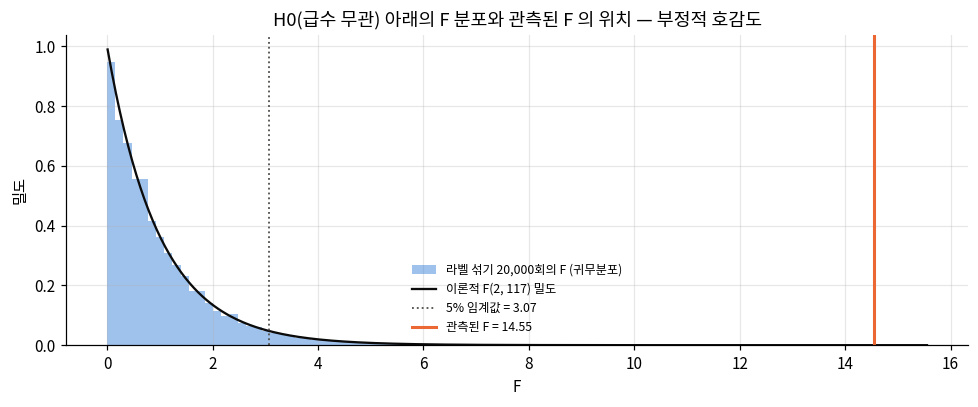

In [16]:
B = 20000
F_null = np.empty(B); SSB_null = np.empty(B)
for b in range(B):
    SSB_null[b], _, F_null[b] = anova_F(y_neg, rng.permutation(g_lab))

print(f"섞기 {B}회:  F 의 평균 = {F_null.mean():.2f}  (이론값 ≈ 1),   SS_B 의 평균 = {SSB_null.mean():.2f}  (이론값 (k-1)/(n-1)·SS_T = {2/119*SST:.2f})")
print(f"            F 의 95% 지점 = {np.percentile(F_null, 95):.2f}   ↔ 이론적 임계값 F(.95; 2, 117) = {stats.f.ppf(.95, 2, 117):.2f}")
print(f"            F 의 99.9% 지점 = {np.percentile(F_null, 99.9):.2f},   최대값 = {F_null.max():.2f}")

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.hist(F_null, bins=80, density=True, color="#2a78d6", alpha=.45, label=f"라벨 섞기 {B:,}회의 F (귀무분포)")
xs = np.linspace(0.01, max(F_obs + 1, 8), 400)
ax.plot(xs, stats.f.pdf(xs, 2, 117), color="#0b0b0b", lw=1.5, label="이론적 F(2, 117) 밀도")
ax.axvline(stats.f.ppf(.95, 2, 117), color="#52514e", ls=":", lw=1.2, label=f"5% 임계값 = {stats.f.ppf(.95, 2, 117):.2f}")
ax.axvline(F_obs, color="#eb6834", lw=2, label=f"관측된 F = {F_obs:.2f}")
ax.set(xlabel="F", ylabel="밀도", title="H0(급수 무관) 아래의 F 분포와 관측된 F 의 위치 — 부정적 호감도")
ax.legend(frameon=False, fontsize=8); ax.grid(alpha=.3); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

**단계 4 — p-값: 관측된 $F$ 이상이 귀무분포에서 차지하는 비율.** 여기서 두 가지를 정확히 해 둔다.

- 가능한 라벨링은 $\binom{120}{33,\,51,\,36}=\dfrac{120!}{33!\,51!\,36!}$ 가지(약 $10^{54}$)이고 원래 라벨링도 그중 하나이므로, 충분히 오래 섞으면 원래 그룹핑도 언젠가 나온다. 그러나 p-값이 묻는 것은 "원래 그룹핑 그 자체가 나올 확률"이 아니라 "**$F \ge F_{obs}$ 인 라벨링들이 전체에서 차지하는 비율**"이다. 원래 라벨링도 이 집합에 속하므로 이 비율은 0 이 아니지만 극히 작다.
- 20,000회는 그 비율을 표본으로 추정한 것이다. "20,000회 중 0회"는 정확히 0 이 아니라 "약 1/20,000 보다 작다"로 읽으며, 관례적으로 관측값 자체를 하나 세어 $p = \dfrac{\#\{F_b \ge F_{obs}\} + 1}{B + 1}$ 로 보고한다.

In [17]:
from math import lgamma, exp, log10
n_labelings_log10 = (lgamma(121) - lgamma(34) - lgamma(52) - lgamma(37)) / np.log(10)
count = int((F_null >= F_obs).sum())
p_perm = (count + 1) / (B + 1)
p_theory = stats.f.sf(F_obs, 2, 117)
print(f"가능한 라벨링의 수 ≈ 10^{n_labelings_log10:.1f}")
print(f"섞기 {B}회 중 F ≥ {F_obs:.2f} 인 횟수 = {count}  →  순열 p = ({count}+1)/({B}+1) = {p_perm:.2e}  (즉 p < {1/B:.0e})")
print(f"이론적 F 분포로 계산한 p = {p_theory:.2e}   (논문: p < .001)")

가능한 라벨링의 수 ≈ 10^54.1
섞기 20000회 중 F ≥ 14.55 인 횟수 = 0  →  순열 p = (0+1)/(20000+1) = 5.00e-05  (즉 p < 5e-05)
이론적 F 분포로 계산한 p = 2.27e-06   (논문: p < .001)


**단계 5 — 결론, 그리고 결론의 정확한 해석.**

논증의 형식은 확률적 귀류법이다: "$H_0$ 가 참이라면 지금처럼 벌어진 집단 평균($F=14.6$)은 거의 나오지 않는다($p<.001$). 그런데 나왔다. 따라서 $H_0$ 를 기각한다." 이것을 논문은 "한국어 수준에 따라 부정적 호감도에 통계적으로 유의한 차이가 있다($F=14.918$, $p<.001$)" 로 쓴다.

**이 결론이 말하는 것**

1. "급수가 무관하다"는 가정 아래서는 이만한 집단 차이가 나올 확률이 극히 작다 — 그래서 그 가정을 버린다.
2. 유의성은 **집단 평균 차이(가설 검정의 결과)** 에 붙는 말이지 데이터셋에 붙는 말이 아니다. "이 데이터가 유의하다"가 아니라 "세 급수의 평균 차이가 유의하다"가 맞는 표현이다.

**이 결론이 말하지 않는 것** — 학생들이 가장 자주 틀리는 세 가지

1. **p 는 "$H_0$ 가 참일 확률"이 아니다.** p 는 "$H_0$ 가 참이라고 가정했을 때 이런 데이터가 나올 확률"이다. 조건의 방향이 반대다. "급수가 무관할 확률이 0.0002 %"라고 말하고 싶다면 그것은 베이즈 분석의 사후확률이고, 짝 노트북(베이즈 판) 7절에서 그 확률을 실제로 계산한다.
2. **p 가 작다는 것이 차이가 크다는 뜻은 아니다.** 표본이 크면 아주 작은 차이도 p 가 작아진다. 차이의 크기는 효과크기로 따로 말해야 한다 — 여기서는 고급−초급 1.2점, $\eta^2 = 0.20$(급수가 개인차의 20 %를 설명).
3. **급수가 원인이라는 뜻이 아니다.** 관찰 자료에서 급수와 함께 달라지는 다른 요인(학습 기간, 전공, 국적 …)이 진짜 원인일 수 있다. 검정은 "연관이 우연이 아니다"까지만 말한다.

그리고 대칭적으로, $p > .05$ 인 요인(예: 자기조절)에 대해 "차이가 없다"고 말하는 것도 오류다. 아래에서 같은 절차를 자기조절에 적용해 보면 "$H_0$ 를 기각할 근거가 없다"는 것과 "차이가 없다"는 것의 차이가 드러난다.

자기조절: 집단 평균 [3.44, 3.33, 3.41],  SS_B = 0.27,  SS_W = 63.9,  F = 0.247
          섞기 20000회 중 F ≥ 0.247 인 비율 = 0.785  →  순열 p = 0.785,  이론 p = 0.782  (논문 p = .765)
          해석: 관측된 집단 차이는 급수가 무관한 세상에서 흔히 나오는 크기 → H₀ 를 기각할 근거가 없다.
                 그러나 '차이가 없다'는 증명은 아니다. 고급−초급 차이 -0.03 점의 95% 신뢰구간은 [-0.38, +0.32] 로 0 을 포함하지만 ±0.4 점까지 열려 있다.


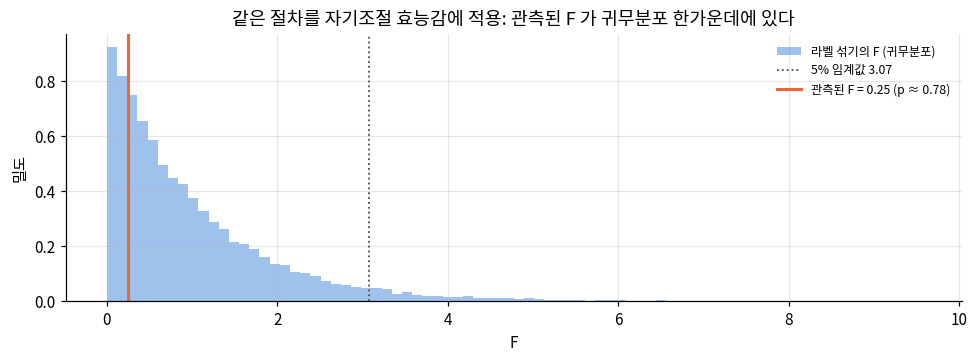

In [18]:
y_sr = S[mask, names.index("자기조절")]
SSB_sr, SSW_sr, F_sr = anova_F(y_sr, g_lab)
F_null_sr = np.array([anova_F(y_sr, rng.permutation(g_lab))[2] for _ in range(B)])
p_perm_sr = ((F_null_sr >= F_sr).sum() + 1) / (B + 1)
print(f"자기조절: 집단 평균 {[round(float(y_sr[g_lab == l].mean()), 2) for l in levels]},  SS_B = {SSB_sr:.2f},  SS_W = {SSW_sr:.1f},  F = {F_sr:.3f}")
print(f"          섞기 {B}회 중 F ≥ {F_sr:.3f} 인 비율 = {(F_null_sr >= F_sr).mean():.3f}  →  순열 p = {p_perm_sr:.3f},  이론 p = {stats.f.sf(F_sr, 2, 117):.3f}  (논문 p = .765)")
print("          해석: 관측된 집단 차이는 급수가 무관한 세상에서 흔히 나오는 크기 → H₀ 를 기각할 근거가 없다.")
d_sr = y_sr[g_lab == 3].mean() - y_sr[g_lab == 1].mean()
half = 1.98 * np.sqrt(SSW_sr / 117 * (1 / 36 + 1 / 33))
print(f"                 그러나 '차이가 없다'는 증명은 아니다. 고급−초급 차이 {d_sr:+.2f} 점의 95% 신뢰구간은 [{d_sr - half:+.2f}, {d_sr + half:+.2f}] 로 0 을 포함하지만 ±0.4 점까지 열려 있다.")
fig, ax = plt.subplots(figsize=(9, 3.4))
ax.hist(F_null_sr, bins=80, density=True, color="#2a78d6", alpha=.45, label="라벨 섞기의 F (귀무분포)")
ax.axvline(stats.f.ppf(.95, 2, 117), color="#52514e", ls=":", lw=1.2, label="5% 임계값 3.07")
ax.axvline(F_sr, color="#eb6834", lw=2, label=f"관측된 F = {F_sr:.2f} (p ≈ {p_perm_sr:.2f})")
ax.set(xlabel="F", ylabel="밀도", title="같은 절차를 자기조절 효능감에 적용: 관측된 F 가 귀무분포 한가운데에 있다")
ax.legend(frameon=False, fontsize=8); ax.grid(alpha=.3); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

**단계별 요약 (학생용)**

| 단계 | 하는 일 | 부정적 호감도 | 자기조절 |
|---|---|---|---|
| 0 | $H_0$: 급수는 무관하다 — 를 잠시 참으로 둔다 | | |
| 1 | 진짜 라벨로 $SS_T$ 를 $SS_B+SS_W$ 로 나누고 $F$ 를 구한다 | $F = 14.6$ | $F = 0.25$ |
| 2 | 점수는 두고 라벨만 섞는다 — $H_0$ 가 참인 세상을 만든다 | | |
| 3 | 20,000번 반복해 $H_0$ 아래 $F$ 의 분포(귀무분포)를 얻는다: 평균 ≈ 1, 95 % 지점 ≈ 3.07 | | |
| 4 | 관측된 $F$ 이상의 비율 = p | $p < 0.0001$ | $p \approx 0.78$ |
| 5 | 결론: $H_0$ 기각 여부와 그 정확한 해석 | 기각 — 차이는 우연으로 보기 어렵다. 크기(1.2점, $\eta^2$=.20)와 인과는 별도 문제 | 기각 못 함 — "차이 없음"의 증명이 아니라 "구분할 수 없음" |

p-값의 정의를 한 문장으로: **"$H_0$ 가 참이라고 가정하고 라벨을 섞었을 때, 관측된 것만큼 극단적인 통계량이 나오는 비율."** 이 문장에서 "가정하고"와 "비율"이 각각 오해 1(조건의 방향)과 오해 2(크기가 아님)를 막아 준다.

## 9. <표 10> 다중회귀분석

논문은 8개 하위 척도를 독립변수로, "학습자가 어려움을 느끼는 쓰기 과제"를 종속변수로 두고 다중회귀분석을 했다.

### 9-1. 최소제곱 추정과 각 열의 의미

절편을 포함한 설계행렬 $X$ (172 × 9), 종속변수 $y$ 에 대해

$$
\hat{B} = (X^\top X)^{-1}X^\top y, \qquad
\hat{y} = X\hat{B}, \qquad e = y-\hat{y}
$$

| 열 | 수식 | 의미 |
|---|---|---|
| $B$ | 위 식 | 다른 변수를 고정한 채 그 변수가 1점 오를 때 $y$ 의 평균 변화(원래 단위) |
| $S.E.$ | $\sqrt{MSE\,[(X^\top X)^{-1}]_{jj}},\ MSE = e^\top e/(n-p)$ | $B$ 추정치의 표준오차(표본을 다시 뽑을 때 $B$ 가 흔들리는 폭) |
| $\beta$ | $B_j \cdot s_{x_j}/s_y$ | 표준화 계수 — 단위를 없애 변수 간 영향력 크기를 비교 |
| $t$ | $B/S.E.$ | 귀무가설 $B_j=0$ 에 대한 검정통계량, $t_{n-p}$ |
| $p$ | $2P(T_{n-p}>\lvert t\rvert)$ | 그 변수의 효과가 0 이라는 가정과의 양립 정도 |
| Tolerance / VIF | $1-R_j^2$, $\ 1/(1-R_j^2)$ | $R_j^2$ = 변수 $j$ 를 나머지 독립변수로 회귀했을 때의 $R^2$. 다중공선성 진단 |
| $F$ | $\dfrac{SSR/(p-1)}{SSE/(n-p)}$ | 모든 계수가 0 이라는 귀무가설(모형 전체의 유의성) |
| $R^2$, adj $R^2$ | $1-\dfrac{SSE}{SST}$, $\ 1-\dfrac{(1-R^2)(n-1)}{n-p}$ | 설명된 분산 비율; adj 는 변수 수에 대한 벌점 |
| D–W | $\dfrac{\sum_{i=2}^n (e_i-e_{i-1})^2}{\sum e_i^2}$ | 잔차의 1차 자기상관 진단, 2 에 가까우면 독립 |

**다중공선성의 직관**: 발상·규칙·자기조절이 서로 .8 이상으로 상관되어 있으면(7절), 회귀는 "셋 중 누구의 공"인지 가려내기 어렵다. 그 결과 $S.E.$ 가 부풀고, 계수의 부호가 상관의 부호와 반대로 튀는 일(억제 효과)이 생긴다. 논문에서 발상($\beta=-.441$)과 규칙($\beta=+.531$)이 서로 반대 부호로 나온 것이 바로 이 현상이다. Tolerance 0.2 는 "그 변수 분산의 80 %가 다른 독립변수로 설명된다"는 뜻이며, VIF 5(= 1/0.2)는 $S.E.$ 의 분산이 공선성 없을 때보다 5 배 부풀었다는 뜻이다.

### 9-2. 이 재현의 범위와 논문 표를 읽을 때의 주의점

- 논문은 종속변수 "어려움을 느끼는 쓰기 과제"를 **어떻게 수치화했는지 밝히지 않았다** (<표 4> 에서는 복수 응답 범주다). 시뮬레이션 데이터에는 그 정보가 없으므로, 여기서는 응답자가 어렵다고 고른 **과제 유형의 개수**(0~5, `diff_*` 열의 합)를 종속변수로 두고 **절차 전체를 재현**한다. 따라서 $B$, $\beta$, $t$, $p$, $F$, $R^2$ 는 논문과 일치하지 않으며 일치할 이유도 없다.
- 반면 **Tolerance/VIF 는 독립변수들만으로 결정**되므로, 상관구조가 논문과 일치하는 이 데이터에서 논문 값과 맞아야 한다. 논문 표의 "VIF" 열(0.205, 0.199, …)은 모두 1 보다 작은데, VIF 는 정의상 1 이상이므로 이 열은 사실 **Tolerance(= 1/VIF)** 다. 아래에서 이를 확인한다.
- 논문 표에는 그 밖에도 내부적으로 맞지 않는 수치가 있다. $F=2.406$ 에 $df=(8,163)$ 이면 $p \approx .018$ 이지 $p<.001$ 이 아니며, 상수항 $S.E.=7.18$ 은 다른 계수의 $S.E.$(0.2~0.7)에 비해 비현실적으로 크다(0.718 의 오기일 가능성). 또 $\beta = B\,s_x/s_y$ 관계로부터 역산한 $s_y$ 가 변수마다 1.0~5.6 으로 달라 어느 한 열에 오기가 있다. 이런 점검이 가능해지는 것이 "수식으로 직접 계산해 보는" 학습의 실질적 이득이다.

**논문 원문 캡처** — <표 10> 학습자가 어려움을 느끼는 쓰기 과제에 쓰기 효능감, 쓰기 상위인지가 미치는 영향

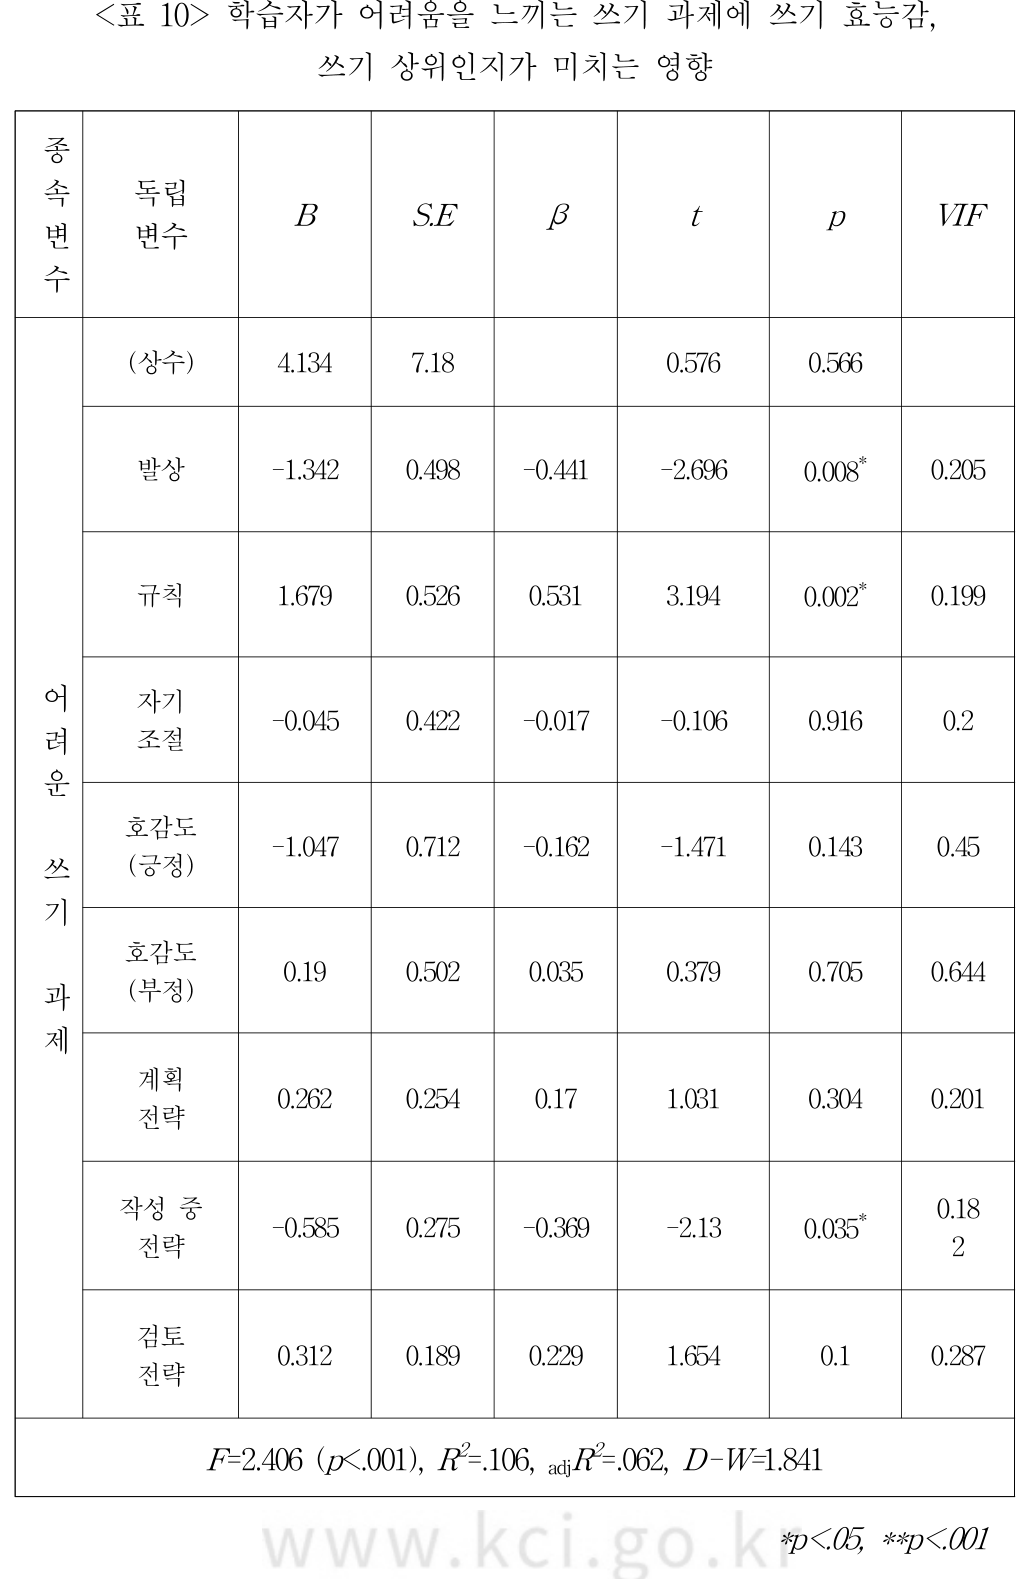

In [19]:
def ols_table(X_raw, y, xnames):
    n, q = X_raw.shape
    X = np.column_stack([np.ones(n), X_raw]); p = X.shape[1]
    XtX_inv = np.linalg.inv(X.T @ X)
    B = XtX_inv @ X.T @ y                         # 최소제곱 추정
    yhat = X @ B; e = y - yhat
    SSE = e @ e; SST = ((y - y.mean()) ** 2).sum(); SSR = SST - SSE
    MSE = SSE / (n - p)
    SE = np.sqrt(MSE * np.diag(XtX_inv))
    t = B / SE
    pval = 2 * stats.t.sf(np.abs(t), df=n - p)
    beta = B[1:] * X_raw.std(axis=0, ddof=1) / y.std(ddof=1)
    # Tolerance / VIF: 각 독립변수를 나머지로 회귀
    tol = np.empty(q)
    for j in range(q):
        Xo = np.column_stack([np.ones(n), np.delete(X_raw, j, axis=1)])
        bj = np.linalg.solve(Xo.T @ Xo, Xo.T @ X_raw[:, j])
        rj = X_raw[:, j] - Xo @ bj
        tol[j] = rj @ rj / ((X_raw[:, j] - X_raw[:, j].mean()) ** 2).sum()      # 1 - R_j^2
    F = (SSR / (p - 1)) / MSE
    Fp = stats.f.sf(F, p - 1, n - p)
    R2 = 1 - SSE / SST
    adjR2 = 1 - (1 - R2) * (n - 1) / (n - p)
    DW = np.sum(np.diff(e) ** 2) / np.sum(e ** 2)
    table = pd.DataFrame({"B": B, "S.E.": SE, "β": np.r_[np.nan, beta], "t": t, "p": pval,
                          "Tolerance": np.r_[np.nan, tol], "VIF": np.r_[np.nan, 1 / tol]}, index=["(상수)"] + xnames)
    return table, dict(F=F, Fp=Fp, R2=R2, adjR2=adjR2, DW=DW, df=(p - 1, n - p))

y_diff = df[[c for c in df.columns if c.startswith("diff_")]].to_numpy().sum(axis=1).astype(float)   # 어렵다고 고른 과제 유형 수
vals, cnts = np.unique(y_diff, return_counts=True)
print("종속변수(어려운 과제 유형 수): 평균 %.2f, SD %.2f, 분포 %s" % (y_diff.mean(), y_diff.std(ddof=1), {int(v): int(c) for v, c in zip(vals, cnts)}))
tab10, fit = ols_table(S, y_diff, names)
print("\n" + tab10.round(3).to_string())
print(f"\nF = {fit['F']:.3f} (df = {fit['df'][0]}, {fit['df'][1]}; p = {fit['Fp']:.3f}),  R² = {fit['R2']:.3f},  adj R² = {fit['adjR2']:.3f},  D–W = {fit['DW']:.3f}")

paper_tol = [0.205, 0.199, 0.200, 0.450, 0.644, 0.201, 0.182, 0.287]
cmp = pd.DataFrame({"논문 'VIF' 열 (실제로는 Tolerance)": paper_tol, "Tolerance (numpy)": tab10["Tolerance"].values[1:].round(3),
                    "VIF (numpy) = 1/Tolerance": tab10["VIF"].values[1:].round(2)}, index=names)
print("\n[다중공선성 진단 비교]"); print(cmp.to_string())
print(f"\n논문 F=2.406, df=(8,163) 일 때의 실제 p-값 = {stats.f.sf(2.406, 8, 163):.4f}  (논문 표기 'p<.001' 과 불일치)")

종속변수(어려운 과제 유형 수): 평균 1.06, SD 0.89, 분포 {0: 49, 1: 75, 2: 38, 3: 8, 4: 2}

          B   S.E.      β      t      p  Tolerance    VIF
(상수)  2.354  0.549    NaN  4.288  0.000        NaN    NaN
발상   -0.528  0.178 -0.433 -2.966  0.003      0.232  4.307
규칙    0.154  0.190  0.121  0.809  0.420      0.221  4.531
자기조절 -0.131  0.187 -0.108 -0.700  0.485      0.210  4.767
긍정   -0.160  0.107 -0.156 -1.488  0.139      0.449  2.229
부정    0.024  0.076  0.028  0.317  0.752      0.642  1.557
계획    0.483  0.178  0.396  2.710  0.007      0.232  4.316
작성   -0.312  0.207 -0.245 -1.510  0.133      0.187  5.335
검토    0.062  0.158  0.051  0.390  0.697      0.287  3.483

F = 4.890 (df = 8, 163; p = 0.000),  R² = 0.194,  adj R² = 0.154,  D–W = 2.040

[다중공선성 진단 비교]
      논문 'VIF' 열 (실제로는 Tolerance)  Tolerance (numpy)  VIF (numpy) = 1/Tolerance
발상                          0.205              0.232                       4.31
규칙                          0.199              0.221                       4.53
자기조절      

### 9-3. 회귀 결과를 읽는 법 (연습)

위 표에서 각 독립변수의 $t$ 와 $p$ 를 보고 "다른 변수를 통제했을 때 그 변수만의 고유한 기여가 0 과 구분되는가"를 판단한다. $R^2$ 는 여덟 변수를 모두 써서 종속변수 분산의 몇 %를 설명했는가이고, adj $R^2$ 가 그보다 눈에 띄게 작으면 변수 수에 비해 설명력이 빈약하다는 뜻이다. 논문의 $R^2=.106$, adj $R^2=.062$ 도 같은 상황이다 — 효능감·전략이 "어려운 과제" 인식의 10 % 정도만 설명하고, 나머지 90 %는 모형 밖 요인이다.

또 하나 확인할 것은 D–W 통계량이다. 잔차 $e_i$ 가 응답 순서에 따라 서로 독립이면 $\sum(e_i-e_{i-1})^2 \approx 2\sum e_i^2$ 이므로 D–W ≈ 2 가 되고, 1.5~2.5 면 대개 문제없다고 본다. 설문 자료에서는 응답 순서에 의미가 없어 이 값이 2 근처로 나오는 것이 자연스럽다.

In [20]:
sig = tab10.iloc[1:].query("p < 0.05")
print("p < .05 인 독립변수:", ", ".join(f"{i} (B={r.B:+.3f}, β={r['β']:+.3f}, p={r.p:.3f})" for i, r in sig.iterrows()) or "없음")
print(f"모형 설명력 R² = {fit['R2']:.3f} → 종속변수 분산의 {100*fit['R2']:.1f}% 설명, adj R² = {fit['adjR2']:.3f}")
print(f"D–W = {fit['DW']:.3f} → 잔차 독립성 가정 {'문제 없음 (1.5~2.5)' if 1.5 < fit['DW'] < 2.5 else '점검 필요'}")
print(f"VIF 최대 = {tab10['VIF'].max():.2f} ({tab10['VIF'].idxmax()}) → " + ("10 미만이지만 5 근처: 효능감 세 요인 사이의 높은 상관(r≈.8) 때문" if tab10['VIF'].max() < 10 else "심각한 다중공선성"))

p < .05 인 독립변수: 발상 (B=-0.528, β=-0.433, p=0.003), 계획 (B=+0.483, β=+0.396, p=0.007)
모형 설명력 R² = 0.194 → 종속변수 분산의 19.4% 설명, adj R² = 0.154
D–W = 2.040 → 잔차 독립성 가정 문제 없음 (1.5~2.5)
VIF 최대 = 5.33 (작성) → 10 미만이지만 5 근처: 효능감 세 요인 사이의 높은 상관(r≈.8) 때문


## 10. 정리

| 논문의 표 | numpy 재현 결과 |
|---|---|
| <표 1>, <표 4> 빈도·비율 | 빈도 완전 일치. 복수 응답 비율은 "응답 수 기준"임을 확인 |
| <표 3> Cronbach's α | 8개 요인 모두 오차 ≤ 0.003 |
| <표 5> M, SD | 소수 둘째 자리까지 일치. '전체' 행은 하위 요인 값의 단순 평균 |
| <표 6> 상위·하위 문항 | 같은 문항이 최고·최저로 선정되고 M·SD 오차 ≤ 0.03 (26번 SD 는 정수 자료의 하한) |
| <표 7> 상관·유의성 | 최대 오차 0.026, 모든 상관이 논문과 같이 $p<.001$ |
| <표 8>, <표 9> ANOVA | 여섯 요인은 논문과 같은 결론(부정 호감도만 유의, 초·중급 < 고급). 긍정·검토는 생성 시 축소 |
| <표 10> 회귀 | 절차 전체 재현. Tolerance(논문의 'VIF' 열)는 일치; 계수는 종속변수 정의가 달라 비교 대상 아님 |

이 노트북의 모든 통계량은 합·평균·행렬곱·역행렬이라는 numpy 기본 연산으로 계산되었고, 분포의 꼬리확률만 scipy 에 맡겼다. 같은 자료에 베이즈 방법을 적용하면, 여기서 점추정치와 p-값으로 요약된 각 양(평균 차이, 상관, 회귀계수, α)이 **사후분포**로 대체된다. 예컨대 ANOVA 의 "$p<.001$" 은 "고급–초급 평균 차이가 0 보다 클 사후확률"로, 회귀의 $S.E.$ 는 계수의 사후 표준편차로 바뀐다. 다음 단계에서 그 대응을 하나씩 확인한다.